# Phase 4 — Exploratory Data Analysis

Phase 3 produced a clean, validated table of 636 discharge cycles from four NASA
lithium-ion cells. This notebook studies that data before any model is built. Its job is to
answer practical questions that decide how the modelling phases should be designed:

1. **What does degradation look like?** Linear, curved, or with a sudden *knee*? Do the
   four cells age the same way?
2. **What drives capacity regeneration** — the upward jumps in capacity?
3. **Which measurements actually track battery health**, and which only appear to because
   they drift with age or are the target in disguise?
4. **Can the unresolved Phase 3 questions be closed?** The early deep discharges, B0018's
   odd impedance, and the 57 cycles with no impedance.

It is written to be read top to bottom. Every section follows the same pattern: *the
question → the analysis → the plot → how to read it → what it means for the project.*
All numbers are computed live from `data/processed/`.

### Contents

| § | Topic |
|---|---|
| 1 | The data, and the corrections applied before analysis |
| 2 | Degradation trajectories — shape, knee, and whether cells age alike |
| 3 | Capacity regeneration — how much is real, and what drives it |
| 4 | Inside a cycle — discharge, charge and temperature curves |
| 5 | Closing Phase 3's open question on deep discharges |
| 6 | Impedance — trends, a measurement offset, and B0018 |
| 7 | Health-indicator screening — what really tracks health |
| 8 | Data quality log |
| 9 | Findings, decisions, and hand-off to Phases 5–6 |

**Files in `phase4_eda/`:** `eda_features.py` (reusable calculations used below),
this notebook, and `outputs/` (screening table and data-quality log written at the end).

---

## 0. Setup

Colour conventions used throughout:

- **Battery identity** — the same four colours as Phase 3, always the same colour for the
  same battery, and every series is labelled directly so nothing relies on colour alone.
- **Cycle number** (when many cycles of one battery are overlaid) — a single blue ramp,
  light for early cycles and dark for late ones, with a colour bar.
- **Red** is reserved for flagged or defective data.

In [1]:
%matplotlib inline
import warnings
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap, Normalize

from common.config import load_config, resolve
from phase4_eda import eda_features as ef

warnings.filterwarnings("ignore")
pd.set_option("display.width", 180)
pd.set_option("display.max_columns", 60)

CFG = load_config()
SERIES = {"B0005": "#2a78d6", "B0006": "#eb6834", "B0007": "#1baf7a", "B0018": "#eda100"}
BATTERIES = list(SERIES)
INK, INK2, MUTED = "#0b0b0b", "#52514e", "#8a8985"
GRID, SURFACE = "#e6e5e1", "#fcfcfb"
ACCENT_BAD = "#e34948"
AGE_CMAP = LinearSegmentedColormap.from_list("age", ["#b9d3f2", "#2a78d6", "#0b2f6b"])

mpl.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE,
    "figure.dpi": 110, "savefig.dpi": 110,
    "font.size": 10, "axes.titlesize": 11, "axes.labelsize": 10,
    "axes.titleweight": "bold", "axes.titlepad": 10,
    "text.color": INK, "axes.labelcolor": INK2,
    "xtick.color": MUTED, "ytick.color": MUTED,
    "axes.edgecolor": GRID, "axes.linewidth": 0.8,
    "legend.frameon": False, "lines.linewidth": 1.6,
})

def style(ax, title=None, xlabel=None, ylabel=None, grid_axis="y"):
    for side in ("top", "right"):
        ax.spines[side].set_visible(False)
    ax.grid(axis=grid_axis, color=GRID, linewidth=0.7)
    ax.set_axisbelow(True)
    if title:  ax.set_title(title, color=INK, loc="left")
    if xlabel: ax.set_xlabel(xlabel)
    if ylabel: ax.set_ylabel(ylabel)
    return ax

def suptitle(fig, text, y=None):
    fig.suptitle(text, color=INK, x=0.012, ha="left", fontsize=11, fontweight="bold")

def end_label(ax, x, y, text, color, dx=5, dy=0):
    ax.annotate(text, (x, y), textcoords="offset points", xytext=(dx, dy),
                fontsize=9, color=color, va="center")

---

## 1. The data, and corrections applied before analysis

### 1.1 Recap

Four 18650 lithium-ion cells (nominal 2.0 Ah) were aged on NASA's testbed at 24 °C by
repeated cycling: charge at 1.5 A to 4.2 V then hold 4.2 V until the current falls to
20 mA; discharge at 2 A down to a per-cell cut-off voltage; and periodic impedance
sweeps. Each row of `cycle_summary` is one discharge, carrying:

- its **capacity** (the target) and discharge aggregates,
- aggregates of the **charge that preceded it**,
- the most recent **impedance** measurement taken before it,
- **quality flags** and **targets** (SOH, end-of-life cycle, remaining useful life).

End of life (EOL) is the first cycle from which capacity stays at or below **1.4 Ah**.
B0005, B0006 and B0018 reach it at cycles 125, 109 and 97. **B0007 never does** — its
remaining life is unknown ("censored").

### 1.2 Corrections applied here, not in the pipeline

While documenting the Phase 3 tables, three defects were found. A fourth came to light at
the start of this phase. They are corrected **inside this notebook** by
`ef.prepare_cycles()`; the Phase 3 pipeline itself is unchanged, so they still need
fixing there.

| # | Defect | Correction used in this EDA |
|---|---|---|
| D1 | `rest_before_h` is the time between discharge **starts**, so it includes the whole charge — it does not measure idle time | Recompute idle time from record start/end times (`idle_total_h`, `idle_chg_to_dis_h`) |
| D2 | A missing relaxation tail is stored as **0** instead of missing | Set `relax_duration_s` and `v_recovery_v` to NaN where there is no tail |
| D3 | Telemetry QC counts only inspect the discharge record | Not needed for EDA; recorded in the data-quality log (§8) |
| D4 | **New.** No charge was logged before cycle 90 of B0005, B0006 and B0007, so the pipeline gave cycle 90 a copy of cycle 89's charge data | Flag as `qc_charge_shared` and exclude those charge features |

In [2]:
T = ef.load_tables()
raw = T["cyc"]
cyc = ef.prepare_cycles(raw)
imp = T["imp"]

print(f"cycles: {len(cyc)}   batteries: {cyc.battery_id.nunique()}   columns after corrections: {cyc.shape[1]}")
print()
print("D4 - discharges that inherited another cycle's charge record:")
print(cyc[cyc.qc_charge_shared][["battery_id", "cycle_id", "charge_start_time", "cc_duration_s"]]
      .to_string(index=False))
print()
prev = cyc[cyc.cycle_id.isin([89, 90]) & (cyc.battery_id == "B0005")]
print("B0005 cycles 89-90 point at the same charge record:")
print(prev[["cycle_id", "op_index", "charge_start_time", "capacity_ah"]].to_string(index=False))
print()
print("D2 - relaxation tails recorded as missing (were 0):")
print(cyc[cyc.relax_tail_missing].groupby("battery_id").cycle_id.agg(n="size", first="min", last="max").to_string())

cycles: 636   batteries: 4   columns after corrections: 71

D4 - discharges that inherited another cycle's charge record:
battery_id  cycle_id       charge_start_time  cc_duration_s
     B0005        90 2008-05-07 23:20:34.515       2696.484
     B0006        90 2008-05-07 23:20:34.515       2447.687
     B0007        90 2008-05-07 23:20:34.515       2944.015

B0005 cycles 89-90 point at the same charge record:
 cycle_id  op_index       charge_start_time  capacity_ah
       89       309 2008-05-07 23:20:34.515     1.517486
       90       312 2008-05-07 23:20:34.515     1.605819

D2 - relaxation tails recorded as missing (were 0):
             n  first  last
battery_id                 
B0006       25      1    31
B0007       29     17    51


**Reading this.** Cycle 90 is a genuine data gap, not a parsing error: the raw file runs
*discharge → impedance → impedance → discharge* with no charge in between. Yet cycle 90
still delivers about 1.6 Ah, which is impossible from an empty cell — so a charge must
have happened that the logger did not record. Section 3 shows that cycle 90 also follows
one of the longest idle periods in the experiment.

The missing relaxation tails are confined to early life: B0006 cycles 1–31 and B0007
cycles 17–51. Treating them as missing rather than zero matters because a recovery of
0 V is physically implausible, and would otherwise read as an extreme value.

The *clean analysis set* used below excludes rows with any QC flag and the D4 rows.

In [3]:
clean = cyc[~cyc.qc_any & ~cyc.qc_charge_shared].copy()
print(f"clean analysis set: {len(clean)} of {len(cyc)} cycles")
print(clean.groupby("battery_id").size().rename("clean_cycles").to_string())

clean analysis set: 603 of 636 cycles
battery_id
B0005    165
B0006    158
B0007    151
B0018    129


---

## 2. Degradation trajectories

### 2.1 The question

The single most important property of the data is the **shape** of each cell's capacity
curve. It determines which models are appropriate: a straight-line decline can be
extrapolated with simple regression, while a curve with a late *knee* — a point where
fade suddenly accelerates — punishes any model that assumes the recent trend continues.

The plot shows capacity against cycle for all four cells, with the EOL threshold.

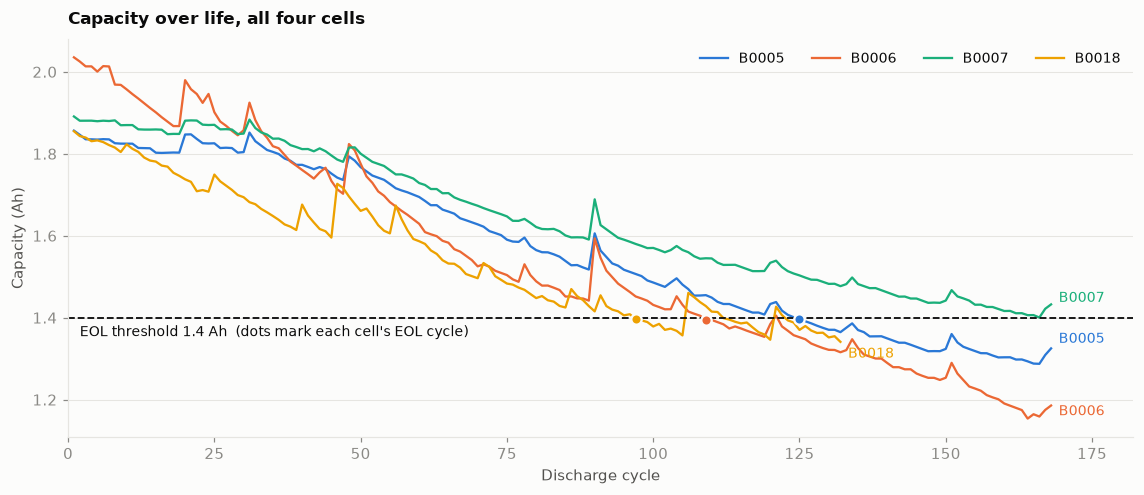

In [4]:
fig, ax = plt.subplots(figsize=(10.5, 4.6))
eol_cap = CFG["targets"]["eol_capacity_ah"]
LABEL_DY = {"B0005": 6, "B0006": -4, "B0007": 4, "B0018": -8}
for b in BATTERIES:
    g = cyc[cyc.battery_id == b]
    ax.plot(g.cycle_id, g.capacity_ah, color=SERIES[b], lw=1.5, label=b)
    end_label(ax, g.cycle_id.iloc[-1], g.capacity_ah.iloc[-1], b, SERIES[b], dy=LABEL_DY[b])
    e = g.eol_cycle.iloc[0]
    if pd.notna(e):
        r = g[g.cycle_id == int(e)].iloc[0]
        ax.scatter([r.cycle_id], [r.capacity_ah], s=46, color=SERIES[b], zorder=5,
                   edgecolor=SURFACE, linewidth=1.5)
ax.axhline(eol_cap, color=INK, lw=1.2, ls="--")
ax.text(2, eol_cap - 0.045, "EOL threshold 1.4 Ah  (dots mark each cell's EOL cycle)",
        fontsize=9, color=INK)
style(ax, "Capacity over life, all four cells", "Discharge cycle", "Capacity (Ah)")
ax.set_xlim(0, 182)
ax.legend(loc="upper right", fontsize=9, ncols=4)
plt.tight_layout(); plt.show()

### How to read it

Every line trends down, but none is smooth: the saw-tooth pattern is capacity regeneration
(§3). Looking past the teeth, the underlying declines look remarkably **straight** — there
is no obvious late collapse in any cell.

The cells differ in both *starting point* and *rate*:

- **B0006** (orange) starts highest, above 2.0 Ah, and falls fastest — it reaches EOL at
  cycle 109.
- **B0018** (yellow) drops steeply in its first 20 cycles, then settles; EOL at cycle 97,
  the earliest.
- **B0005** (blue) and **B0007** (green) run almost parallel for their whole lives. B0005
  crosses at cycle 125; B0007 finishes just above the line and never crosses.

Starting capacity does not predict lifetime: the highest-capacity cell is not the
longest-lived one.

### 2.2 Is there a knee?

A visual impression of straightness needs testing. Two checks:

1. Fit a straight line to each trajectory and measure how much variation it explains (R²).
2. Fit the **best two-piece straight line**, trying every breakpoint. If a knee exists,
   the second piece will be clearly steeper than the first.

In [5]:
rows = []
for b in BATTERIES:
    g = cyc[cyc.battery_id == b]
    fit = ef.two_segment_fit(g.cycle_id.to_numpy(), g.capacity_ah.to_numpy())
    rows.append({
        "battery": b,
        "linear R2": fit["linear_r2"],
        "linear slope (mAh/cycle)": fit["linear_slope"] * 1000,
        "two-piece R2": fit["two_segment_r2"],
        "break at cycle": int(fit["break_x"]),
        "slope before": fit["slope_1"] * 1000,
        "slope after": fit["slope_2"] * 1000,
    })
shape = pd.DataFrame(rows).set_index("battery")
shape["after / before"] = shape["slope after"] / shape["slope before"]
print(shape.round(3).to_string())

         linear R2  linear slope (mAh/cycle)  two-piece R2  break at cycle  slope before  slope after  after / before
battery                                                                                                              
B0005        0.976                    -3.867         0.988              62        -2.180       -3.573           1.639
B0006        0.964                    -5.087         0.988              90        -6.966       -4.214           0.605
B0007        0.976                    -3.269         0.989              60        -2.238       -2.816           1.258
B0018        0.940                    -3.926         0.972             106        -4.640       -3.206           0.691


### How to read the table

**A straight line already explains 94–98% of the variation.** Allowing a breakpoint only
lifts that to 97–99%, which is a small gain given that the extra flexibility would always
improve the fit somewhat.

The ratio column is the knee test. A knee would show a ratio well above 1 (fade getting
much faster later):

- **B0005** (1.6×) and **B0007** (1.3×) do accelerate mildly after about cycle 60.
- **B0006** (0.6×) and **B0018** (0.7×) do the opposite — they fade *faster early* and
  slow down later.

**There is no knee in this data.** That matches what the experiment was designed to do:
NASA stopped cycling at 30% capacity fade, before the late-life collapse that is typical
of lithium-ion cells aged further. It has a direct consequence: models trained here have
never seen a knee, and should not be trusted to predict one.

### 2.3 How the fade rate changes over life

The table gives one slope per phase. A rolling slope shows the rate cycle by cycle. The
slope below uses only the **previous** 20 cycles at each point, so it is exactly what a
live monitoring system could compute.

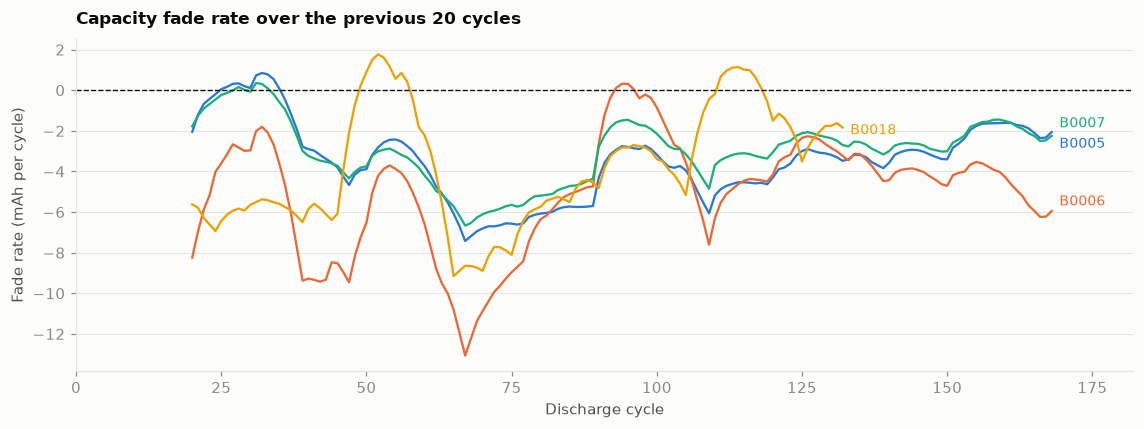

In [6]:
fig, ax = plt.subplots(figsize=(10.5, 4.0))
LABEL_DY = {"B0005": -8, "B0006": 6, "B0007": 8, "B0018": -2}
for b in BATTERIES:
    g = cyc[cyc.battery_id == b]
    rate = ef.backward_slope(g.capacity_ah.reset_index(drop=True), 20) * 1000
    ax.plot(g.cycle_id.to_numpy(), rate.to_numpy(), color=SERIES[b], lw=1.5)
    last = rate.dropna()
    end_label(ax, g.cycle_id.iloc[-1], last.iloc[-1], b, SERIES[b], dy=LABEL_DY[b])
ax.axhline(0, color=INK, lw=0.9, ls="--")
style(ax, "Capacity fade rate over the previous 20 cycles", "Discharge cycle",
      "Fade rate (mAh per cycle)")
ax.set_xlim(0, 182)
plt.tight_layout(); plt.show()

### How to read it

Values below zero mean capacity is falling; the further below, the faster. The first 19
cycles are blank because the window needs 20 cycles of history.

The rate is **not constant** — it swings between about +2 and −13 mAh/cycle. The swings
line up with regeneration: when capacity jumps back up, the backward slope briefly flattens
or even turns positive, then steepens again as the recovered capacity fades away.

Two practical points:

- **A 20-cycle window is noisy.** A fade-rate feature for a live twin needs either a longer
  window or a smoothed input, or it will report false "improvements" after every rest.
- **B0006 and B0018 fade faster than B0005 and B0007 through roughly cycles 20–70** — B0006
  reaches −13 mAh/cycle around cycle 67 — consistent with the table: those two cells
  front-load their degradation.

### 2.4 Do the cells age alike?

Two cells can reach EOL at different cycles yet follow the same *path*. Re-scaling each
cell's cycle count by its own EOL cycle ("life fraction", where 1.0 = EOL) tests this. If
all cells followed one universal curve, the lines would collapse on top of each other.
B0007 is left out because it has no EOL to scale by.

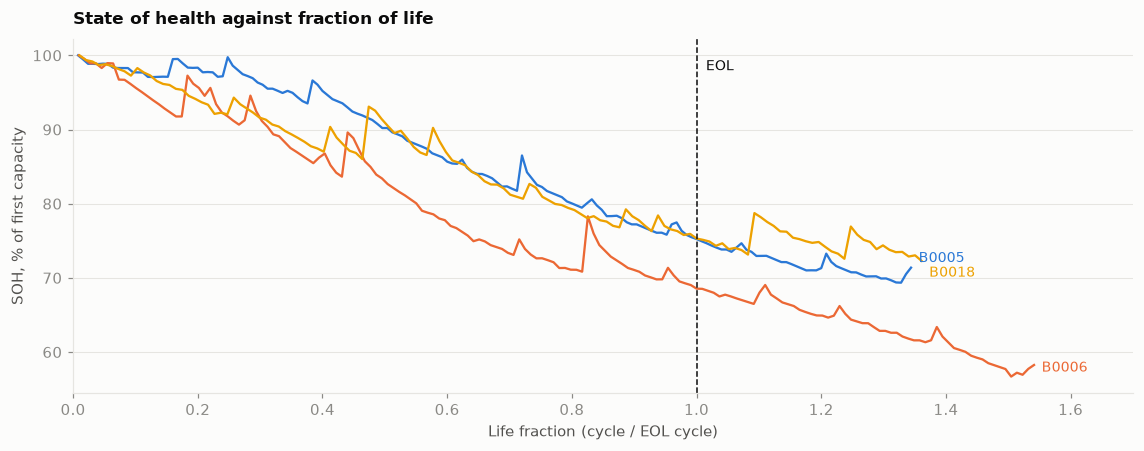

 life fraction  B0005  B0006  B0018  spread (pp)
          0.25  99.46  91.64  92.61         7.82
          0.50  90.20  83.02  90.93         7.91
          0.75  82.32  72.64  81.23         9.69
          1.00  75.23  68.55  75.30         6.75


In [7]:
fig, ax = plt.subplots(figsize=(10.5, 4.2))
LABEL_DY = {"B0005": 6, "B0006": -2, "B0018": -8}
for b in ["B0005", "B0006", "B0018"]:
    g = cyc[cyc.battery_id == b]
    ax.plot(g.life_fraction, g.soh_pct_self, color=SERIES[b], lw=1.5)
    end_label(ax, g.life_fraction.iloc[-1], g.soh_pct_self.iloc[-1], b, SERIES[b], dy=LABEL_DY[b])
ax.axvline(1.0, color=INK, lw=1.0, ls="--")
ax.text(1.015, 98, "EOL", fontsize=9, color=INK)
style(ax, "State of health against fraction of life", "Life fraction (cycle / EOL cycle)",
      "SOH, % of first capacity")
ax.set_xlim(0, 1.7)
plt.tight_layout(); plt.show()

rows = []
for lf in [0.25, 0.5, 0.75, 1.0]:
    vals = {b: float(np.interp(lf, g.life_fraction, g.soh_pct_self))
            for b, g in cyc[~cyc.is_censored].groupby("battery_id")}
    rows.append({"life fraction": lf, **vals, "spread (pp)": max(vals.values()) - min(vals.values())})
print(pd.DataFrame(rows).round(2).to_string(index=False))

### How to read it

The curves do **not** collapse onto one line. The gap between the highest and lowest cell
stays at roughly 7–10 percentage points of SOH throughout life (table). **B0006 sits lowest
all the way** — at a quarter of its life it has already lost 8% while B0005 has lost less
than 1%.

B0005 and B0018 end up close at EOL, but they get there differently: B0018 loses health
early and B0005 late (both visible in the curves).

**What this means.** A cell's SOH does not pin down how far through its life it is: the
three cells first reach 80% SOH at life fractions of 0.56 (B0006), 0.77 (B0018) and 0.81
(B0005). Cross-battery RUL prediction will carry a real,
irreducible error from cell-to-cell variation — and with only three labelled cells, that
variation is barely sampled.

### 2.5 Does early fade predict lifetime?

Early prediction — estimating lifetime from the first few cycles — is the most valuable
thing a prognostics model can do. A simple check: how much capacity has each cell lost by
cycle 20, and how does that line up with when it reaches EOL?

In [8]:
rows = []
for b in BATTERIES:
    g = cyc[cyc.battery_id == b].set_index("cycle_id")
    e = g.eol_cycle.iloc[0]
    at_eol = g.loc[int(e)] if pd.notna(e) else None
    rows.append({
        "battery": b,
        "start capacity (Ah)": g.capacity_ah.loc[1],
        "loss by cycle 20 (mAh)": (g.capacity_ah.loc[1] - g.capacity_ah.loc[20]) * 1000,
        "loss by cycle 50 (mAh)": (g.capacity_ah.loc[1] - g.capacity_ah.loc[50]) * 1000,
        "EOL cycle": "never (censored)" if at_eol is None else int(e),
        "days to EOL": np.nan if at_eol is None else at_eol.elapsed_days,
        "Ah delivered to EOL": np.nan if at_eol is None else at_eol.coulomb_throughput_ah,
    })
early = pd.DataFrame(rows).set_index("battery")
print(early.round({"start capacity (Ah)": 3, "loss by cycle 20 (mAh)": 1, "loss by cycle 50 (mAh)": 1,
                   "days to EOL": 1, "Ah delivered to EOL": 1}).to_string())

         start capacity (Ah)  loss by cycle 20 (mAh)  loss by cycle 50 (mAh)         EOL cycle  days to EOL  Ah delivered to EOL
battery                                                                                                                         
B0005                  1.856                     9.5                    89.1               125         45.1                206.3
B0006                  2.035                    55.7                   259.6               109         41.2                184.5
B0007                  1.891                    10.3                    90.8  never (censored)          NaN                  NaN
B0018                  1.855                   117.3                   194.3                97         33.2                157.7


### How to read it

Sort the cells by capacity lost in the first 20 cycles: **B0018 (117 mAh) → B0006 (56) →
B0007 (10) → B0005 (9.5)**. Now sort by EOL: **B0018 (97) → B0006 (109) → B0005 (125)**,
with B0007 outliving the experiment. The orderings agree for the three cells that
reached EOL — early fade is a promising early-life signal.

The caveat has to be stated just as clearly: this is a ranking of **three** labelled
cells. Three items can be ordered six ways, so a perfect agreement would occur by chance
one time in six. It is a hypothesis worth carrying into modelling, not a result.

The last two columns show that cells reaching EOL sooner also do so in fewer days and
after delivering less total charge (158–206 Ah): cycle count, elapsed time and throughput
all tell a consistent story here, because every cell ran the same protocol.

---

## 3. Capacity regeneration

### 3.1 How many of the jumps are real?

Phase 3 counted every cycle where capacity rose above the previous cycle: 21–47 per
battery. But a rise of 0.1 mAh is measurement noise, not recovery. The histogram shows the
size of every cycle-to-cycle change, with a ±5 mAh band marked.

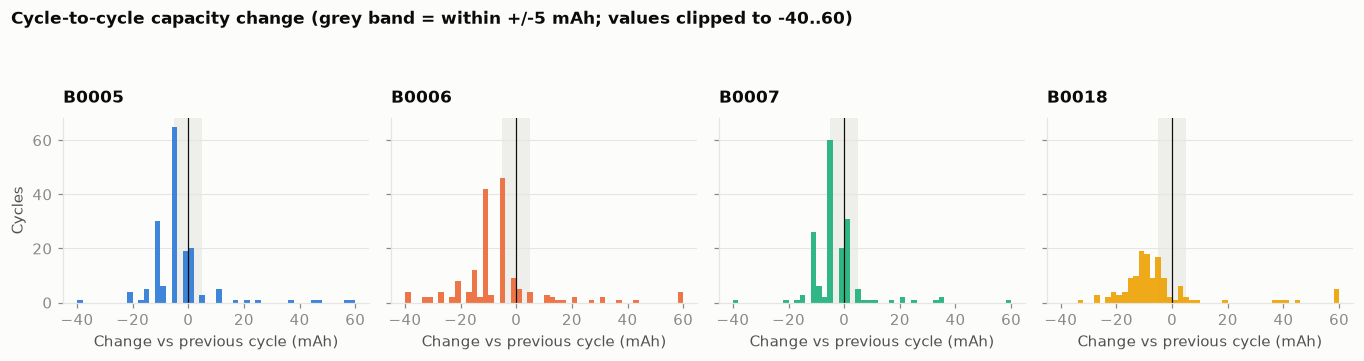

         steps  any rise  rise > 5 mAh  rise > 20 mAh within +/-1 mAh
battery                                                              
B0005      167        36            15              7             22%
B0006      167        27            20             11              8%
B0007      167        47            14              7             28%
B0018      131        21            13              9              2%


In [9]:
cyc["dcap_mah"] = cyc.groupby("battery_id").capacity_ah.diff() * 1000

fig, axes = plt.subplots(1, 4, figsize=(12.5, 3.3), sharey=True)
for ax, b in zip(axes, BATTERIES):
    d = cyc.loc[cyc.battery_id == b, "dcap_mah"].dropna()
    ax.hist(d.clip(-40, 60), bins=np.arange(-40, 62, 2), color=SERIES[b], alpha=0.9)
    ax.axvspan(-5, 5, color=GRID, alpha=0.6, lw=0, zorder=0)
    ax.axvline(0, color=INK, lw=0.8)
    style(ax, b, "Change vs previous cycle (mAh)", "Cycles" if b == "B0005" else None)
    ax.title.set_fontsize(10)
suptitle(fig, "Cycle-to-cycle capacity change (grey band = within +/-5 mAh; values clipped to -40..60)")
plt.tight_layout(rect=[0, 0, 1, 0.9]); plt.show()

rows = []
for b in BATTERIES:
    d = cyc.loc[cyc.battery_id == b, "dcap_mah"].dropna()
    rows.append({"battery": b, "steps": len(d), "any rise": int((d > 0).sum()),
                 "rise > 5 mAh": int((d > 5).sum()), "rise > 20 mAh": int((d > 20).sum()),
                 "within +/-1 mAh": f"{(d.abs() <= 1).mean():.0%}"})
print(pd.DataFrame(rows).set_index("battery").to_string())

### How to read it

Most changes cluster just below zero: a small loss each cycle. The grey band holds the
bulk of the data. Real regeneration is the thin tail stretching to the **right** of the
band.

The table separates the two. Of B0007's 47 counted rises, only **14 exceed 5 mAh**;
across the four cells, meaningful rises number 13–20, and large ones (>20 mAh) only a
handful. A large share of cycles (up to 28% for B0007) change by 1 mAh or less — the
capacity sits on a plateau.

**Correction to Phase 3.** The regeneration counts in `regeneration_summary` overstate how
often cells meaningfully recover, by 1.4 to 3.4 times depending on the cell. The robust statistic is the size of the
largest jumps, not the count.

### 3.2 Measuring idle time correctly

Regeneration is expected to follow **rest**: while a cell sits idle, lithium concentration
gradients inside it even out, so the next discharge can extract more charge. Testing that
requires a true idle measure.

The pipeline's `rest_before_h` is not one (defect D1): it spans from one discharge start to
the next, so it includes a ~1 h discharge and a ~3 h charge. The corrected measure,
`idle_total_h`, subtracts the time spent charging and discharging.

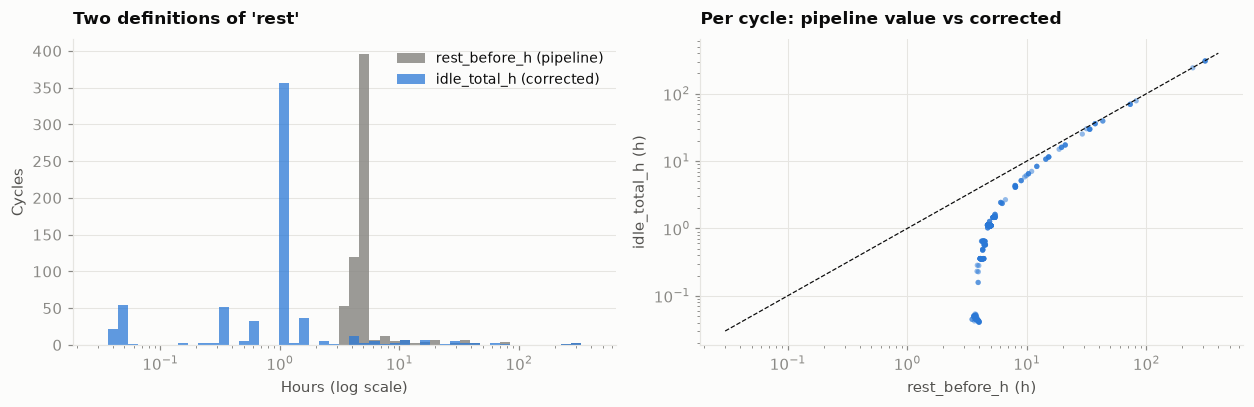

     rest_before_h  idle_total_h  idle_chg_to_dis_h
min           3.48          0.04               0.02
5%            3.75          0.04               0.02
50%           4.87          1.11               0.55
95%          14.43         10.68               0.84
max         310.40        306.60              34.07


In [10]:
fig, (a1, a2) = plt.subplots(1, 2, figsize=(11.5, 3.8))
x = cyc.dropna(subset=["rest_before_h", "idle_total_h"])
bins = np.logspace(np.log10(0.03), np.log10(400), 50)
a1.hist(x.rest_before_h, bins=bins, color=MUTED, alpha=0.85, label="rest_before_h (pipeline)")
a1.hist(x.idle_total_h, bins=bins, color=SERIES["B0005"], alpha=0.75, label="idle_total_h (corrected)")
a1.set_xscale("log")
style(a1, "Two definitions of 'rest'", "Hours (log scale)", "Cycles")
a1.legend(fontsize=9, loc="upper right")

a2.scatter(x.rest_before_h, x.idle_total_h, s=12, color=SERIES["B0005"], alpha=0.5, edgecolor="none")
lim = [0.03, 400]
a2.plot(lim, lim, color=INK, lw=0.8, ls="--")
a2.set_xscale("log"); a2.set_yscale("log")
style(a2, "Per cycle: pipeline value vs corrected", "rest_before_h (h)", "idle_total_h (h)", grid_axis="both")
plt.tight_layout(); plt.show()

print(x[["rest_before_h", "idle_total_h", "idle_chg_to_dis_h"]]
      .describe(percentiles=[0.05, 0.5, 0.95]).loc[["min", "5%", "50%", "95%", "max"]].round(2).to_string())

### How to read it

**Left:** the pipeline's value (grey) can never fall below about 3 hours — the time taken
by one discharge plus one charge. The corrected idle time (blue) spans from a couple of
minutes to hundreds of hours, with a median around one hour.

**Right:** each dot is a cycle. For short idles the pipeline value is pinned around 3–5 h
whatever the true idle was, so it cannot distinguish a 3-minute pause from a 1-hour one.
Only for very long rests (the upper right) do the two measures converge.

### 3.3 Does idle time drive regeneration?

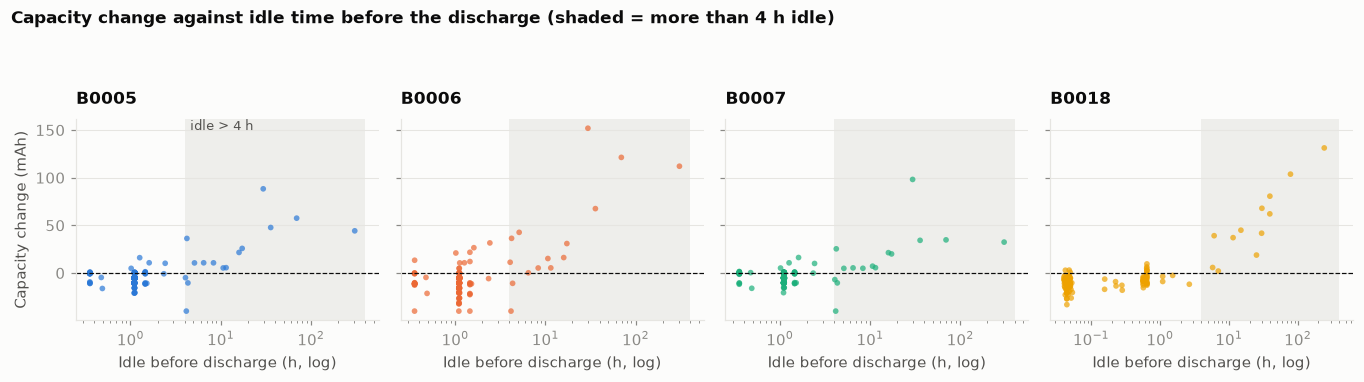

In [11]:
fig, axes = plt.subplots(1, 4, figsize=(12.5, 3.5), sharey=True)
for ax, b in zip(axes, BATTERIES):
    g = cyc[(cyc.battery_id == b)].dropna(subset=["dcap_mah", "idle_total_h"])
    ax.axvspan(4, 400, color=GRID, alpha=0.6, lw=0, zorder=0)
    ax.scatter(g.idle_total_h, g.dcap_mah.clip(-40, 160), s=14, color=SERIES[b], alpha=0.7,
               edgecolor="none")
    ax.axhline(0, color=INK, lw=0.8, ls="--")
    ax.set_xscale("log")
    style(ax, b, "Idle before discharge (h, log)", "Capacity change (mAh)" if b == "B0005" else None)
    ax.title.set_fontsize(10)
axes[0].text(4.6, 150, "idle > 4 h", fontsize=8.5, color=INK2)
suptitle(fig, "Capacity change against idle time before the discharge (shaded = more than 4 h idle)")
plt.tight_layout(rect=[0, 0, 1, 0.9]); plt.show()

In [12]:
d = cyc.dropna(subset=["dcap_mah", "idle_total_h"]).copy()
d["idle band"] = pd.cut(d.idle_total_h, [0, 1, 4, 24, 1000],
                        labels=["< 1 h", "1-4 h", "4-24 h", "> 24 h"])
summary = d.groupby("idle band", observed=True).agg(
    cycles=("dcap_mah", "size"),
    share_rising=("dcap_mah", lambda s: (s > 5).mean()),
    median_change_mAh=("dcap_mah", "median"),
)
print("All batteries pooled; 'rising' = capacity up by more than 5 mAh")
print(summary.round(3).to_string())
print()
top = d.nlargest(12, "dcap_mah")[["battery_id", "cycle_id", "dcap_mah", "idle_total_h", "qc_charge_shared"]]
print("The 12 largest capacity jumps:")
print(top.round(1).to_string(index=False))
print()
print("Spearman correlation of capacity change with idle time, per battery:")
for b, g in d.groupby("battery_id"):
    print(f"  {b}:  idle_total_h {g.dcap_mah.corr(g.idle_total_h, method='spearman'):+.2f}"
          f"   vs pipeline rest_before_h {g.dcap_mah.corr(g.rest_before_h, method='spearman'):+.2f}")

All batteries pooled; 'rising' = capacity up by more than 5 mAh
           cycles  share_rising  median_change_mAh
idle band                                         
< 1 h         172         0.017             -8.871
1-4 h         403         0.035             -5.374
4-24 h         38         0.684              6.451
> 24 h         19         1.000             67.547

The 12 largest capacity jumps:
battery_id  cycle_id  dcap_mah  idle_total_h  qc_charge_shared
     B0006        90     151.9          29.7              True
     B0018        46     131.2         242.5             False
     B0006        48     121.3          69.6             False
     B0006        20     112.0         306.6             False
     B0018       106     103.7          78.5             False
     B0007        90      98.2          29.7              True
     B0005        90      88.3          29.7              True
     B0018       121      80.6          39.4             False
     B0018        56      67.9 

### How to read it

**The scatter plots** show the pattern plainly. Left of the shaded region (under 4 hours
idle), points hug the zero line or fall slightly below it. Inside the shaded region almost
every point sits **above** zero, and the further right, the taller the jump.

**The table** turns this into a rate. After less than 1 hour idle, capacity rises by more
than 5 mAh in under 2% of cycles; after 1–4 hours, under 4%. After 4–24 hours it rises in
68% of cycles, and after more than a day in **all 19**. The switch is sharp, somewhere
around 4 hours. **Every one of the 12 largest jumps follows more than a day of idle.**

**The correlations** explain why Phase 3 missed this. Spearman correlation measures a
steady monotone trend, but the effect here behaves like a **threshold**: short rests do
little, long rests produce a jump. Most cycles have short rests, so the correlation stays
modest. It is also stronger with the corrected idle time than with the pipeline's
`rest_before_h` for three of the four cells, and equal for B0018.

**Correction to Phase 3.** The Phase 3 findings notebook concluded that rest had only a
weak relationship with regeneration. That conclusion was produced by the wrong variable.
With idle time measured correctly, **long idle periods are the dominant driver of large
capacity jumps.**

Two cycles in the top 12 mark **test-rig interruptions** rather than routine rests. Cycle
90 (`qc_charge_shared = True`) follows a ~30-hour gap in which the charge was never logged
(defect D4). Cycle 31 of B0006 — and of B0005 and B0007, which ran on the same schedule —
follows a 36-hour gap in which only a 9-second charge stub was logged. The capacity
measurements themselves are sound; the logging around them is not. §4.4 shows the rig was
also reconfigured at cycle 31.

### 3.4 Plateaus: capacity moves in steps

Section 3.1 noted that many consecutive cycles change by under 1 mAh. The zoom below
checks whether that is a quirk of how the recorded `Capacity` value was stored, by
overlaying charge computed independently from the current (`discharge_ah`).

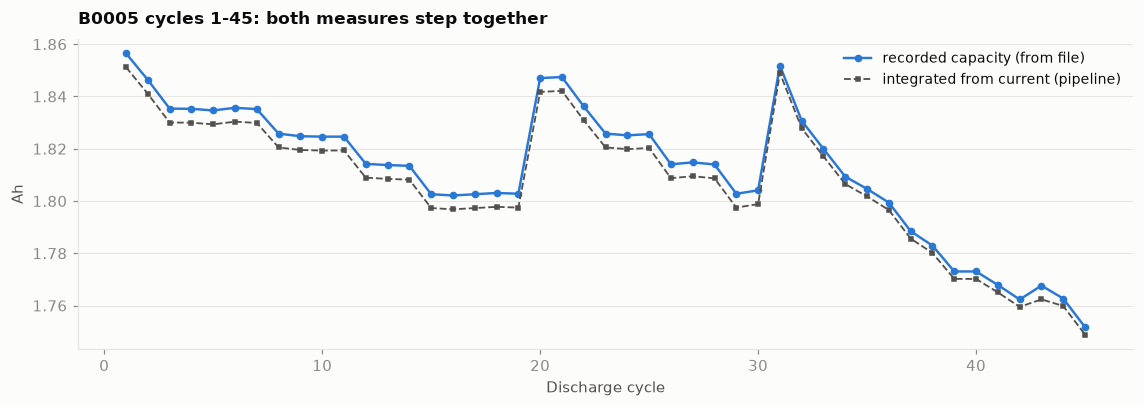

B0005: correlation of cycle-to-cycle changes, recorded vs integrated = 1.000
B0006: correlation of cycle-to-cycle changes, recorded vs integrated = 0.985
B0007: correlation of cycle-to-cycle changes, recorded vs integrated = 0.943
B0018: correlation of cycle-to-cycle changes, recorded vs integrated = 0.977


In [13]:
g = cyc[(cyc.battery_id == "B0005") & (cyc.cycle_id <= 45)]
fig, ax = plt.subplots(figsize=(10.5, 3.8))
ax.plot(g.cycle_id, g.capacity_ah, color=SERIES["B0005"], lw=1.6, marker="o", ms=4,
        label="recorded capacity (from file)")
ax.plot(g.cycle_id, g.discharge_ah, color=INK2, lw=1.2, ls="--", marker="s", ms=3,
        label="integrated from current (pipeline)")
style(ax, "B0005 cycles 1-45: both measures step together", "Discharge cycle", "Ah")
ax.legend(fontsize=9, loc="upper right")
plt.tight_layout(); plt.show()

for b, gg in cyc.groupby("battery_id"):
    r = gg.capacity_ah.diff().corr(gg.discharge_ah.diff())
    print(f"{b}: correlation of cycle-to-cycle changes, recorded vs integrated = {r:.3f}")

### How to read it

The two lines — one read from the file, one integrated independently from the measured
current — move **together**, offset by a constant ~5 mAh. Both show the same flat runs of
several cycles broken by small drops, and both show the jump at cycle 20.

So the plateaus are real behaviour of the discharges, not a storage artefact. The ~5 mAh
offset is a small systematic difference between NASA's capacity calculation and the
trapezoid integration used here; it is constant, so it does not affect trends.

### 3.5 Decision: raw capacity or a smoothed envelope?

| Option | For | Against |
|---|---|---|
| **Raw capacity** as the target | It is what was measured; regeneration is real | Short-term jumps driven by rest, not health, add target noise |
| **Causal envelope** (e.g. running minimum) | Represents the irreversible loss a twin cares about | Discards genuine usable capacity after rest |

**Decision:** keep **raw capacity** as the primary SOH target, and give models the
information to explain the jumps — `idle_total_h` as a feature. Evaluate the envelope as a
secondary target in Phase 7. Any smoothing must be backward-looking only; a centred
smoother would leak future cycles into the target.

---

## 4. Inside a cycle

Aggregates like capacity summarise each cycle as one number. The raw curves in `telemetry`
show *how* the cell's behaviour changes, and they are where the richest features come from.
Each plot overlays many cycles of **B0005** coloured from light (early) to dark (late).

### 4.1 Discharge voltage against charge delivered

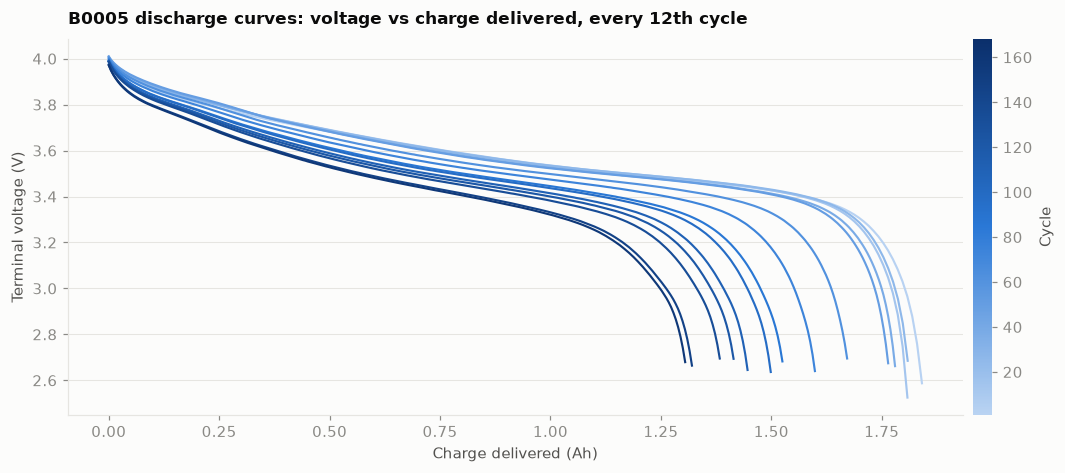

In [14]:
tel5 = ef.load_discharge_telemetry("B0005")
show = list(range(2, 169, 12))
norm = Normalize(1, 168)

fig, ax = plt.subplots(figsize=(10.5, 4.4))
for cid in show:
    q, v, t = ef.active_qv(tel5[tel5.cycle_id == cid])
    ax.plot(q, v, color=AGE_CMAP(norm(cid)), lw=1.4)
sm = mpl.cm.ScalarMappable(norm=norm, cmap=AGE_CMAP)
cb = fig.colorbar(sm, ax=ax, pad=0.01); cb.set_label("Cycle", color=INK2); cb.outline.set_visible(False)
style(ax, "B0005 discharge curves: voltage vs charge delivered, every 12th cycle",
      "Charge delivered (Ah)", "Terminal voltage (V)")
plt.tight_layout(); plt.show()

### How to read it

Each curve is one discharge, read left to right: the cell starts near 4 V, falls quickly,
runs along a long gently-sloping **plateau** around 3.4–3.8 V, then drops sharply when it
is nearly empty. Where the curve ends on the x-axis is that cycle's capacity.

As the cell ages (lighter → darker), two things happen:

1. **The curves get shorter.** Dark curves end further left — less charge delivered before
   the cut-off. This is capacity fade.
2. **The curves shift down.** At any given amount of charge delivered, the voltage of an
   older cell is lower. The cell's internal resistance has risen, so more voltage is lost
   inside it at 2 A. This is power fade, and it is why energy falls slightly faster than
   capacity.

The plateau region is where the more detailed curve analysis below looks.

### 4.2 Charge curves: the constant-current phase shrinks

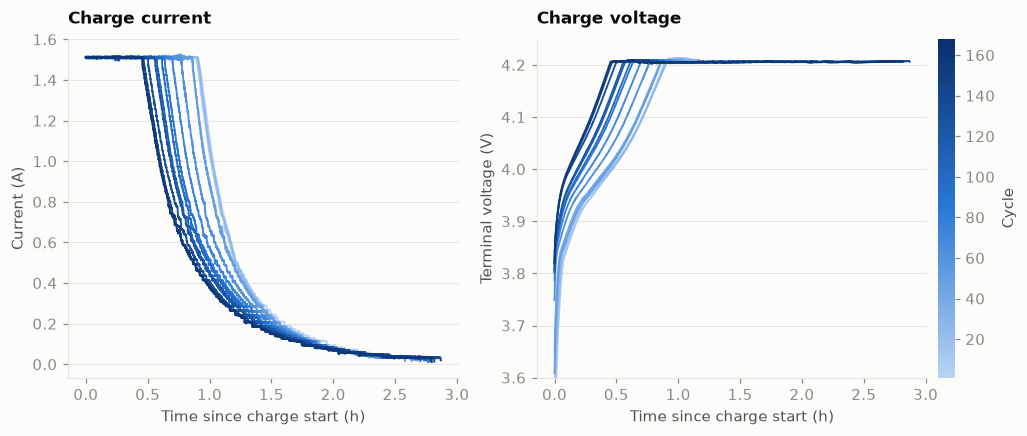

In [15]:
chg5 = pd.read_parquet(resolve("processed") / "telemetry.parquet",
                       filters=[("battery_id", "==", "B0005"), ("cycle_type", "==", "charge")])
fig, (a1, a2) = plt.subplots(1, 2, figsize=(12, 4.0), sharex=True)
for cid in show:
    g = chg5[(chg5.cycle_id == cid)].sort_values("t_rel_s")
    g = g[g.current_a > 0.01]
    t_h = (g.t_rel_s - g.t_rel_s.iloc[0]) / 3600
    a1.plot(t_h, g.current_a, color=AGE_CMAP(norm(cid)), lw=1.2)
    a2.plot(t_h, g.voltage_v, color=AGE_CMAP(norm(cid)), lw=1.2)
style(a1, "Charge current", "Time since charge start (h)", "Current (A)")
style(a2, "Charge voltage", "Time since charge start (h)", "Terminal voltage (V)")
a2.set_ylim(3.6, 4.25)
cb = fig.colorbar(sm, ax=[a1, a2], pad=0.01); cb.set_label("Cycle", color=INK2); cb.outline.set_visible(False)
plt.show()

### How to read it

**Left (current):** every charge begins with a flat line at 1.5 A — the constant-current
(CC) phase — then the current decays in a long curve toward zero — the constant-voltage
(CV) phase. The corner where the flat line turns into the decay is the CC→CV transition.

As the cell ages that corner moves **left**: dark curves leave the 1.5 A line sooner.

**Right (voltage):** voltage climbs during CC until it reaches the 4.2 V ceiling, then
stays there for the whole CV phase. Older cells hit the ceiling sooner.

Both panels show the same mechanism. An aged cell has less capacity to fill *and* a higher
internal resistance; the extra resistive voltage makes the terminal voltage reach 4.2 V
while the cell is still less full, ending the CC phase early. This is the physical basis of
`cc_duration_s`, which §7 identifies as the best health indicator available *before* a
discharge.

### 4.3 Temperature during discharge

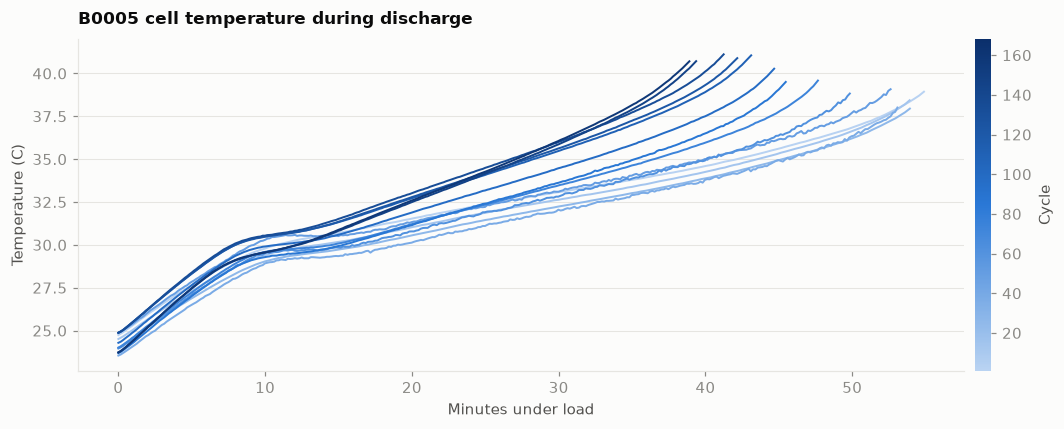

B0005 temp rise under load: first 10 clean cycles 14.0 C, last 10 17.0 C
B0005 peak temperature:     first 10 clean cycles 38.6 C, last 10 40.9 C


In [16]:
fig, ax = plt.subplots(figsize=(10.5, 4.0))
for cid in show:
    g = tel5[tel5.cycle_id == cid].sort_values("t_rel_s")
    g = g[np.abs(g.current_a) > 0.5]
    ax.plot((g.t_rel_s - g.t_rel_s.iloc[0]) / 60, g.temperature_c, color=AGE_CMAP(norm(cid)), lw=1.3)
cb = fig.colorbar(sm, ax=ax, pad=0.01); cb.set_label("Cycle", color=INK2); cb.outline.set_visible(False)
style(ax, "B0005 cell temperature during discharge", "Minutes under load", "Temperature (C)")
plt.tight_layout(); plt.show()

g = clean[clean.battery_id == "B0005"]
print(f"B0005 temp rise under load: first 10 clean cycles {g.temp_rise_c.head(10).median():.1f} C,"
      f" last 10 {g.temp_rise_c.tail(10).median():.1f} C")
print(f"B0005 peak temperature:     first 10 clean cycles {g.temp_max_c.head(10).median():.1f} C,"
      f" last 10 {g.temp_max_c.tail(10).median():.1f} C")

### How to read it

Every discharge warms the cell from about 24 °C, rising fastest in the first ten minutes and
again at the very end as the voltage collapses. Older cells (dark) **stop sooner** — their
discharges last about 40 minutes instead of 55 — yet they **end hotter**, because they heat
faster throughout. That is consistent with higher internal resistance turning more of the
2 A current into heat.

The printed numbers confirm it for B0005: the temperature rise under load grows from about
14 °C to 17 °C, and the peak from about 38.6 °C to 40.9 °C. §7 shows temperature rise is a
consistent indicator within each cell, but weaker when cells are pooled, because the cells
differ in how much they heat to begin with.

### 4.4 A hidden confound: the sampling rate changes with age

Curve features — slopes, derivatives, peak heights — are sensitive to how densely the curve
was sampled. The logger's sampling interval was **not constant**.

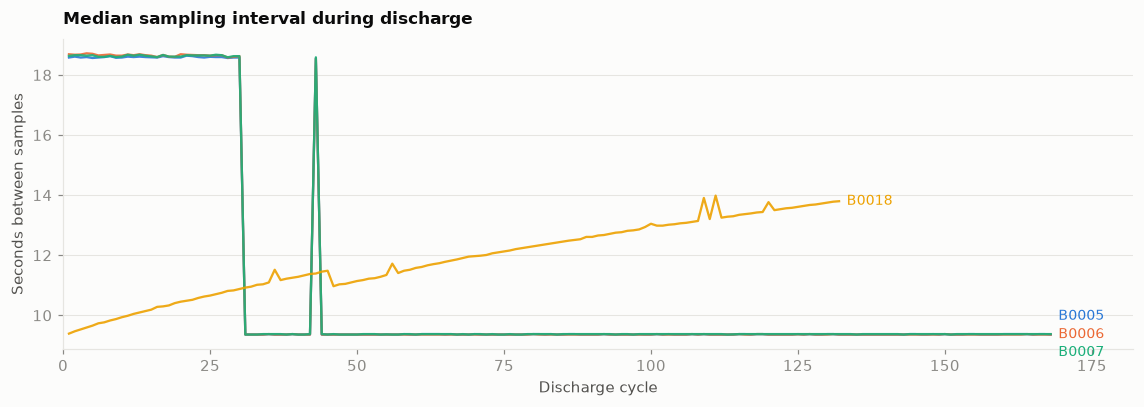

B0005: starts 18.6 s, ends 9.4 s; step changes: cycle 31 -> 9.4 s, cycle 43 -> 18.5 s, cycle 44 -> 9.4 s
B0006: starts 18.7 s, ends 9.4 s; step changes: cycle 31 -> 9.4 s, cycle 43 -> 18.5 s, cycle 44 -> 9.4 s
B0007: starts 18.6 s, ends 9.4 s; step changes: cycle 31 -> 9.4 s, cycle 43 -> 18.6 s, cycle 44 -> 9.4 s
B0018: starts 9.4 s, ends 13.8 s; step changes: none


In [17]:
curves = ef.discharge_curve_features(ef.load_discharge_telemetry(), ef.cutoffs())
cyc = cyc.merge(curves, on=["battery_id", "cycle_id"], how="left")
clean = clean.merge(curves, on=["battery_id", "cycle_id"], how="left")

fig, ax = plt.subplots(figsize=(10.5, 3.8))
LABEL_DY = {"B0005": 12, "B0006": 0, "B0007": -12, "B0018": 0}
for b in BATTERIES:
    g = cyc[cyc.battery_id == b]
    ax.plot(g.cycle_id, g.dt_median_s, color=SERIES[b], lw=1.5, alpha=0.9)
    end_label(ax, g.cycle_id.iloc[-1], g.dt_median_s.iloc[-1], b, SERIES[b], dy=LABEL_DY[b])
style(ax, "Median sampling interval during discharge", "Discharge cycle", "Seconds between samples")
ax.set_xlim(0, 182)
plt.tight_layout(); plt.show()

for b in BATTERIES:
    g = cyc[cyc.battery_id == b].sort_values("cycle_id")
    jumps = g[g.dt_median_s.diff().abs() > 2][["cycle_id", "dt_median_s"]]
    steps = ", ".join(f"cycle {int(r.cycle_id)} -> {r.dt_median_s:.1f} s" for _, r in jumps.iterrows()) or "none"
    print(f"{b}: starts {g.dt_median_s.iloc[0]:.1f} s, ends {g.dt_median_s.iloc[-1]:.1f} s; step changes: {steps}")

### How to read it

B0005, B0006 and B0007 share one logger schedule (their lines overlap exactly). They sample
every **~18.6 s for cycles 1–30**, then switch in a single step to **~9.4 s from cycle 31**,
apart from one cycle (43) that briefly returns to 18.5 s. B0018 follows a different pattern
entirely, drifting gradually from ~9.4 s to ~13.8 s over its life.

**Cycle 31 was a test-rig event.** For B0005–B0007 it coincides with a 36-hour stop, a
9-second aborted charge record (Phase 3), a large capacity jump (§3.3) and this logger
change. Cycle 43 is a smaller version: a ~11-hour gap and the one-cycle sampling blip.
These breaks matter beyond sampling — §6.1 shows an impedance step at the same point.

**Why this matters.** Sampling rate and age change together. A feature computed from the
curve's shape can correlate with age simply because the curve was drawn with more or fewer
points. For B0005–B0007 the risk is a **step at cycle 31**. For B0018 sampling and age
drift together across the whole life and **cannot be separated** from this data.

**Decision for Phase 6:** resample every curve onto a fixed voltage or time grid before
computing shape features, and check any curve feature against cycles 32 onward of B0005–B0007 (excluding 43), where
sampling is constant.

### 4.5 Incremental capacity analysis (dQ/dV)

A discharge curve's plateau hides detail. Taking the derivative of charge with respect to
voltage — *how much charge is delivered per volt of drop* — turns flat plateau regions into
**peaks**. Each peak corresponds to an electrochemical phase transition in the electrodes:

- **Peak height** falls when active electrode material is lost.
- **Peak position** shifts when usable lithium is lost.

This is the most physically informative curve feature, and the most sensitive to noise, so
it is computed on a fixed 10 mV voltage grid with smoothing (`ef.ica_curve`).

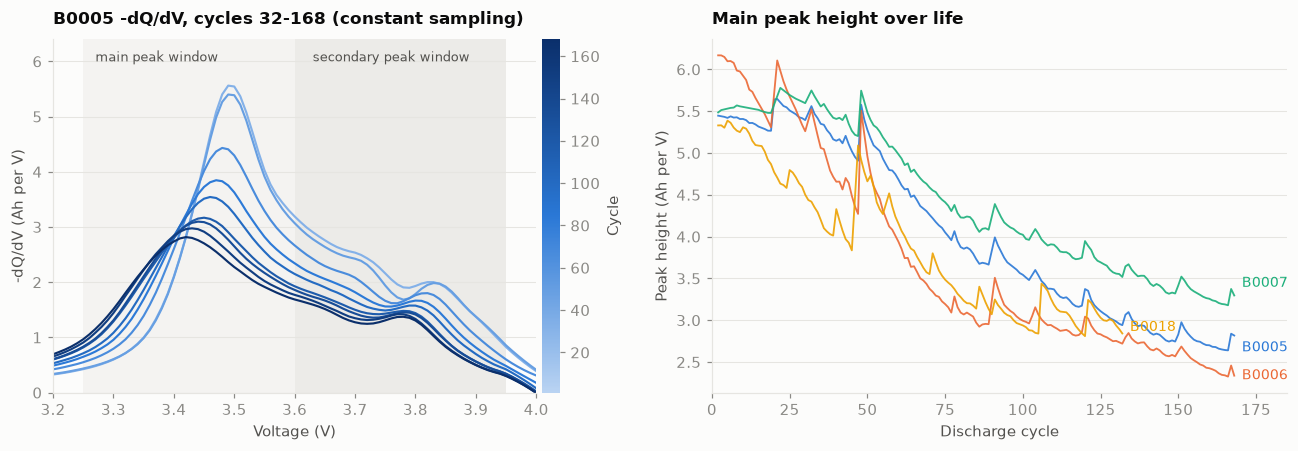

In [18]:
fig, (a1, a2) = plt.subplots(1, 2, figsize=(12, 4.2))
for lo, hi in (ef.ICA_MAIN_WINDOW, ef.ICA_SECONDARY_WINDOW):
    a1.axvspan(lo, hi, color=GRID, alpha=0.35 if lo < 3.6 else 0.7, lw=0, zorder=0)
for cid in list(range(32, 169, 17)):
    q, v, t = ef.active_qv(tel5[tel5.cycle_id == cid])
    a1.plot(ef.ICA_GRID, ef.ica_curve(q, v), color=AGE_CMAP(norm(cid)), lw=1.4)
a1.set_xlim(3.2, 4.0); a1.set_ylim(0, 6.4)
a1.text(3.27, 6.0, "main peak window", fontsize=8.5, color=INK2)
a1.text(3.63, 6.0, "secondary peak window", fontsize=8.5, color=INK2)
style(a1, "B0005 -dQ/dV, cycles 32-168 (constant sampling)", "Voltage (V)", "-dQ/dV (Ah per V)")
cb = fig.colorbar(sm, ax=a1, pad=0.01); cb.set_label("Cycle", color=INK2); cb.outline.set_visible(False)

for b in BATTERIES:
    g = clean[clean.battery_id == b].dropna(subset=["ica_p1_h"])
    a2.plot(g.cycle_id, g.ica_p1_h, color=SERIES[b], lw=1.2, alpha=0.9)
    end_label(a2, g.cycle_id.iloc[-1], g.ica_p1_h.iloc[-1], b, SERIES[b],
              dy={"B0005": -8, "B0006": 0, "B0007": 8, "B0018": 4}[b])
style(a2, "Main peak height over life", "Discharge cycle", "Peak height (Ah per V)")
a2.set_xlim(0, 185)
plt.tight_layout(); plt.show()

In [19]:
band = pd.cut(cyc.cycle_id, [0, 20, 40, 60, 100, 170])
for col, name in [("ica_p1_v", "main peak (~3.45 V)"), ("ica_p2_v", "secondary peak (~3.8 V)")]:
    print(f"Share of cycles with NO {name} detected:")
    print(cyc.assign(miss=cyc[col].isna()).pivot_table(index=band, columns="battery_id", values="miss",
          aggfunc="mean", observed=True).round(2).to_string())
    print()
for b in BATTERIES:
    g = clean[clean.battery_id == b]
    print(f"{b}: main peak {g.ica_p1_v.head(10).median():.2f} V -> {g.ica_p1_v.tail(10).median():.2f} V, "
          f"height {g.ica_p1_h.head(10).median():.2f} -> {g.ica_p1_h.tail(10).median():.2f};  "
          f"Spearman with SOH: height {g.ica_p1_h.corr(g.soh_pct_self, method='spearman'):.3f}, "
          f"position {g.ica_p1_v.corr(g.soh_pct_self, method='spearman'):.3f}")

Share of cycles with NO main peak (~3.45 V) detected:
battery_id  B0005  B0006  B0007  B0018
cycle_id                              
(0, 20]       0.0    0.0    0.0    0.0
(20, 40]      0.0    0.0    0.0    0.0
(40, 60]      0.0    0.0    0.0    0.0
(60, 100]     0.0    0.0    0.0    0.0
(100, 170]    0.0    0.0    0.0    0.0

Share of cycles with NO secondary peak (~3.8 V) detected:
battery_id  B0005  B0006  B0007  B0018
cycle_id                              
(0, 20]       1.0   1.00    1.0   1.00
(20, 40]      0.5   0.30    0.5   0.55
(40, 60]      0.0   0.00    0.0   0.00
(60, 100]     0.0   0.00    0.0   0.00
(100, 170]    0.0   0.13    0.0   0.00

B0005: main peak 3.49 V -> 3.42 V, height 5.43 -> 2.68;  Spearman with SOH: height 0.996, position 0.977
B0006: main peak 3.49 V -> 3.30 V, height 6.09 -> 2.38;  Spearman with SOH: height 0.997, position 0.995
B0007: main peak 3.50 V -> 3.43 V, height 5.51 -> 3.23;  Spearman with SOH: height 0.995, position 0.978
B0018: main peak 3.48 V -

### How to read it

**Left:** each curve is the incremental capacity of one B0005 discharge, using cycles 32
onward so the sampling rate is constant. There are **two** peaks, one in each shaded window:
a tall **main peak** near 3.4–3.5 V and a smaller **secondary peak** near 3.8 V. As the cell
ages (darker), both get **lower** and move **left** to lower voltage — the two signatures
described above, in the direction battery physics predicts.

**Right:** the main peak's height over life tracks the capacity curves of §2 closely for all
four cells, including their regeneration jumps. It roughly halves over life for B0005.

**The coverage tables separate the two peaks.** The **main peak is detected in every cycle of
every cell**, from cycle 1. The **secondary peak is never detected in cycles 1–20**, and in
only about half of cycles 21–40 — early in life it does not form a separate maximum. So the
main peak is usable across the whole life; the secondary one only after roughly cycle 40.

The main peak's height correlates almost perfectly with SOH (0.99–1.00), and its position
nearly as well. That strength needs care: the peak comes from the **same discharge** that
measures capacity, so it is close to being the target measured another way. §7 deals with
this.

---

## 5. Closing Phase 3's open question: do deep discharges inflate capacity?

### The question

Phase 3 found 21 early-life discharges (B0006 cycles 10–26, B0007 cycles 4–29) that went
about 0.3 V **below** their documented cut-off voltage. A deeper discharge extracts more
charge, so their recorded capacity might overstate the cell's health — distorting the SOH
reference point right where early prediction works.

### The test

Recompute each discharge's capacity **stopping exactly at the documented cut-off**, using
the telemetry curve (`q_to_cutoff_ah`), and compare it with the recorded capacity. If the
deep discharges inflated capacity, the flagged cycles will show a clearly larger excess
than the rest.

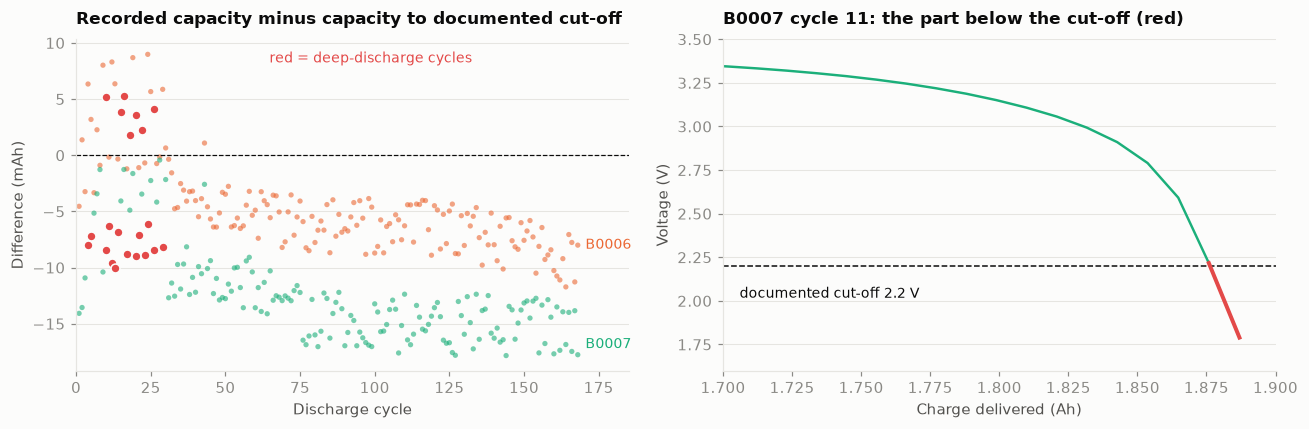

                               cycles  mean  largest
battery_id qc_cutoff_mismatch                       
B0005      False                  168   6.6     16.1
B0006      False                  161  -5.0      9.0
           True                     7   3.7      5.2
B0007      False                  154 -13.0     -0.4
           True                    14  -8.1     -6.2
B0018      False                  132  -3.3      1.0


In [20]:
cyc["excess_mah"] = (cyc.capacity_ah - cyc.q_to_cutoff_ah) * 1000

fig, (a1, a2) = plt.subplots(1, 2, figsize=(12, 4.0))
for b in ["B0006", "B0007"]:
    g = cyc[cyc.battery_id == b]
    ok, bad = g[~g.qc_cutoff_mismatch], g[g.qc_cutoff_mismatch]
    a1.scatter(ok.cycle_id, ok.excess_mah, s=12, color=SERIES[b], alpha=0.6, edgecolor="none")
    a1.scatter(bad.cycle_id, bad.excess_mah, s=34, color=ACCENT_BAD, edgecolor=SURFACE, lw=1, zorder=5)
    end_label(a1, g.cycle_id.iloc[-1], g.excess_mah.iloc[-5:].median(), b, SERIES[b])
a1.axhline(0, color=INK, lw=0.8, ls="--")
style(a1, "Recorded capacity minus capacity to documented cut-off", "Discharge cycle",
      "Difference (mAh)")
a1.set_xlim(0, 185)
a1.text(0.35, 0.93, "red = deep-discharge cycles", transform=a1.transAxes, fontsize=9, color=ACCENT_BAD)

q, v, t = ef.active_qv(ef.load_discharge_telemetry("B0007").query("cycle_id == 11"))
a2.plot(q, v, color=SERIES["B0007"], lw=1.6)
a2.axhline(CFG["cutoff_voltage_v"]["B0007"], color=INK, lw=1.0, ls="--")
a2.text(0.03, 0.22, "documented cut-off 2.2 V", transform=a2.transAxes, fontsize=9, color=INK)
k = int(np.argmax(v <= CFG["cutoff_voltage_v"]["B0007"]))
a2.plot(q[k - 1:], v[k - 1:], color=ACCENT_BAD, lw=2.6)
style(a2, "B0007 cycle 11: the part below the cut-off (red)", "Charge delivered (Ah)", "Voltage (V)")
a2.set_xlim(1.70, 1.90); a2.set_ylim(1.6, 3.5)
plt.tight_layout(); plt.show()

print(cyc.groupby(["battery_id", "qc_cutoff_mismatch"]).excess_mah
         .agg(cycles="size", mean="mean", largest="max").round(1).to_string())

### How to read it

**Left:** every dot is one discharge. The y-axis is how much more charge the recorded
capacity contains than a discharge stopped exactly at the cut-off would have delivered. All
values sit within about ±16 mAh — under 1% of capacity — and the red deep-discharge cycles
fall **inside** the same band as everything else. They are not systematically higher.

**Right** shows why. The red segment is the part of one deep discharge that went below
2.2 V. It is almost **vertical**: at the very end of a discharge the voltage collapses so
fast that another 0.3 V of depth adds only a sliver of charge.

**Result:** the table confirms flagged and unflagged cycles have similar, small differences.
**The deep discharges do not meaningfully inflate recorded capacity.** Phase 3's open
Finding 5 is closed: the `qc_cutoff_mismatch` flag can stay for traceability, but those 21
cycles do **not** need to be excluded from SOH or RUL work.

---

## 6. Impedance

### 6.1 Resistance over life

Two fitted resistances come from each impedance sweep:

- **Re** — electrolyte resistance, the simple ohmic part.
- **Rct** — charge-transfer resistance, the resistance of the electrode reaction itself.

Both are expected to **rise** as a cell degrades. These plots use the `impedance` table
directly (one point per sweep), not the forward-filled copy in `cycle_summary`.

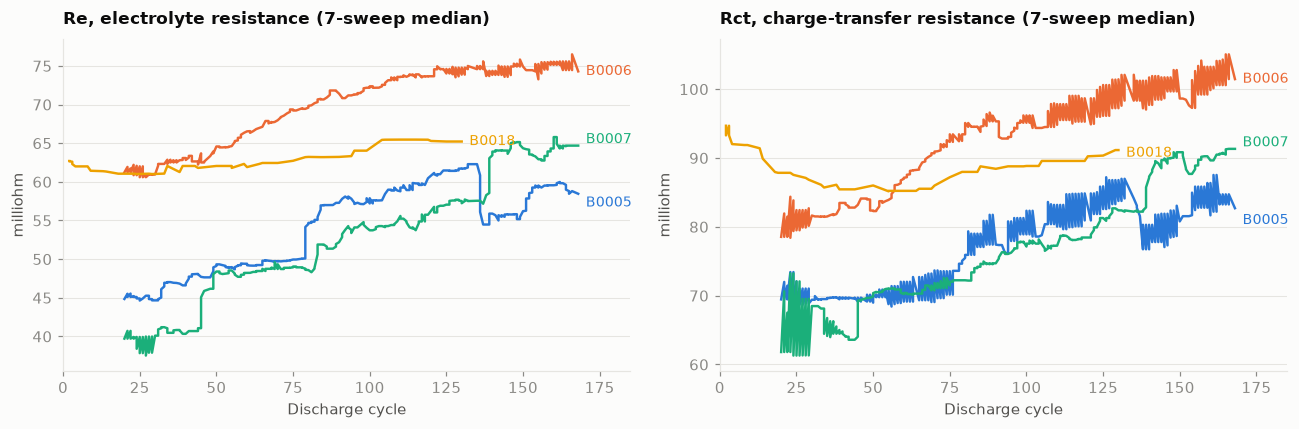

         sweeps Re first->last 10 (mOhm) Rct first->last 10 (mOhm)  Spearman capacity~Re  Spearman capacity~Rct
battery                                                                                                        
B0005       278             45.0 -> 58.2              71.4 -> 84.0                 -0.79                  -0.81
B0006       278             61.7 -> 75.0             81.2 -> 103.3                 -0.93                  -0.93
B0007       278             39.8 -> 64.7              67.5 -> 91.3                 -0.96                  -0.93
B0018        52             61.7 -> 65.4              91.8 -> 90.3                 -0.76                  -0.10


In [21]:
ictx = ef.impedance_with_context(imp, raw)

fig, (a1, a2) = plt.subplots(1, 2, figsize=(12, 4.0))
for b in BATTERIES:
    g = ictx[ictx.battery_id == b].dropna(subset=["cycle_id"])
    sm_re = g.re_ohm.rolling(7, min_periods=3).median()
    sm_rct = g.rct_ohm.rolling(7, min_periods=3).median()
    a1.plot(g.cycle_id, sm_re * 1000, color=SERIES[b], lw=1.6)
    a2.plot(g.cycle_id, sm_rct * 1000, color=SERIES[b], lw=1.6)
    end_label(a1, g.cycle_id.iloc[-1], sm_re.iloc[-1] * 1000, b, SERIES[b],
              dy={"B0005": -6, "B0006": 0, "B0007": 4, "B0018": 0}[b])
    end_label(a2, g.cycle_id.iloc[-1], sm_rct.iloc[-1] * 1000, b, SERIES[b],
              dy={"B0005": -8, "B0006": 0, "B0007": 4, "B0018": -2}[b])
style(a1, "Re, electrolyte resistance (7-sweep median)", "Discharge cycle", "milliohm")
style(a2, "Rct, charge-transfer resistance (7-sweep median)", "Discharge cycle", "milliohm")
for a in (a1, a2): a.set_xlim(0, 185)
plt.tight_layout(); plt.show()

rows = []
for b, g in ictx.dropna(subset=["cycle_id"]).groupby("battery_id"):
    rows.append({"battery": b, "sweeps": len(g),
                 "Re first->last 10 (mOhm)": f"{g.re_ohm.head(10).median()*1000:.1f} -> {g.re_ohm.tail(10).median()*1000:.1f}",
                 "Rct first->last 10 (mOhm)": f"{g.rct_ohm.head(10).median()*1000:.1f} -> {g.rct_ohm.tail(10).median()*1000:.1f}",
                 "Spearman capacity~Re": round(g.capacity_ah.corr(g.re_ohm, method="spearman"), 2),
                 "Spearman capacity~Rct": round(g.capacity_ah.corr(g.rct_ohm, method="spearman"), 2)})
print(pd.DataFrame(rows).set_index("battery").to_string())

### How to read it

A rolling median over 7 sweeps is plotted because single sweeps are noisy. The rapid zig-zag
still visible for B0005–B0007 is not random noise: consecutive sweeps alternate between two
measurement conditions that read differently (§6.2). The occasional vertical steps are real
discontinuities — B0007's Re, for example, jumps about 7 mΩ between cycles 42 and 44, across
the test-rig break described in §4.4.

For **B0005, B0006 and B0007**, both resistances climb steadily with age, and both
correlate strongly and negatively with capacity (−0.79 to −0.96): as resistance goes up,
capacity goes down, as expected.

The lines start at cycle 20, not cycle 1, because these three cells had no impedance sweep
before then — the 57 missing values from Phase 3.

**B0018 is different, but only in Rct.** Its Re (left) rises normally. Its Rct (right)
starts at about 91 mΩ — a level the other cells reach only near end of life — dips in
mid-life, then climbs back. Its correlation with capacity collapses to about −0.1.

### 6.2 A measurement offset: what happened just before the sweep matters

Impedance depends on the cell's condition at the moment of measurement. Sweeps in this
data follow either a **charge** (cell full) or a **discharge** (cell empty). If that
matters, sweeps of the two kinds taken in the same cycle should disagree systematically.

         sweeps after charge  sweeps after discharge  cycles with both  median Rct(after dis) - Rct(after chg), mOhm share of cycles lower after discharge  lifetime Rct rise, mOhm
battery                                                                                                                                                                            
B0005                    136                     142               135                                         -4.75                                   92%                     12.5
B0006                    136                     142               135                                         -2.93                                   76%                     22.1
B0007                    136                     142               135                                         -0.50                                   61%                     23.8
B0018                     23                      29                 4                              

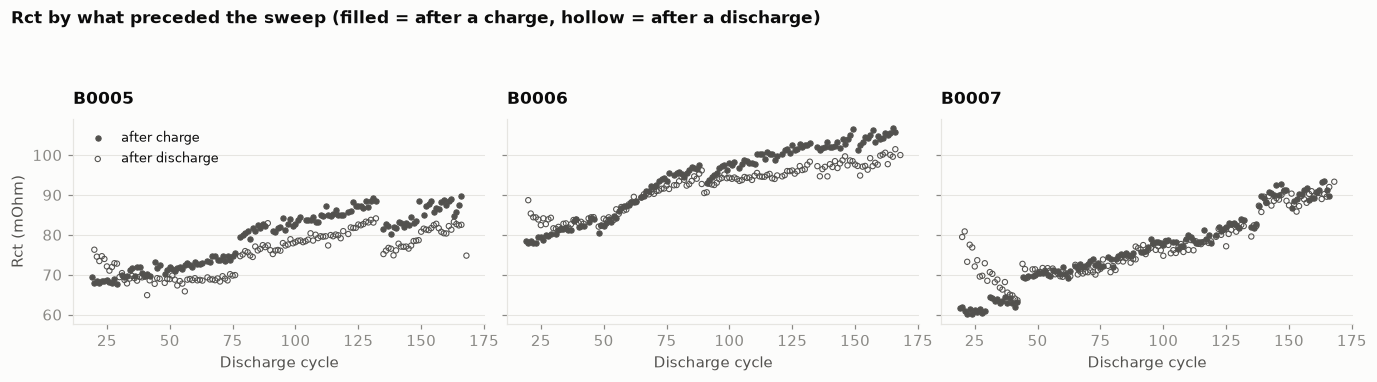

In [22]:
rows = []
for b, g in ictx.dropna(subset=["cycle_id"]).groupby("battery_id"):
    p = g.pivot_table(index="cycle_id", columns="after", values="rct_ohm", aggfunc="median").dropna()
    diff = (p["discharge"] - p["charge"]) * 1000 if {"charge", "discharge"} <= set(p.columns) else pd.Series(dtype=float)
    life_rise = (g.rct_ohm.tail(10).median() - g.rct_ohm.head(10).median()) * 1000
    rows.append({"battery": b,
                 "sweeps after charge": int((g.after == "charge").sum()),
                 "sweeps after discharge": int((g.after == "discharge").sum()),
                 "cycles with both": len(p),
                 "median Rct(after dis) - Rct(after chg), mOhm": round(diff.median(), 2) if len(diff) else np.nan,
                 "share of cycles lower after discharge": f"{(diff < 0).mean():.0%}" if len(diff) else "-",
                 "lifetime Rct rise, mOhm": round(life_rise, 1)})
print(pd.DataFrame(rows).set_index("battery").to_string())
print()
print("The same offset by stage of life (median mOhm, after discharge minus after charge):")
band = pd.cut(ictx.cycle_id, [0, 44, 90, 130, 170])
tab = {}
for b, g in ictx.dropna(subset=["cycle_id"]).groupby("battery_id"):
    if b == "B0018":
        continue
    col = {}
    for bd, gb in g.groupby(band.loc[g.index], observed=True):
        p = gb.pivot_table(index="cycle_id", columns="after", values="rct_ohm", aggfunc="median").dropna()
        col[f"cycles {bd}"] = round(float(((p["discharge"] - p["charge"]) * 1000).median()), 2)
    tab[b] = col
print(pd.DataFrame(tab).to_string())

fig, axes = plt.subplots(1, 3, figsize=(12.5, 3.5), sharey=True)
for ax, b in zip(axes, ["B0005", "B0006", "B0007"]):
    g = ictx[(ictx.battery_id == b)].dropna(subset=["cycle_id"])
    for kind, face in [("charge", INK2), ("discharge", "none")]:
        k = g[g.after == kind]
        ax.scatter(k.cycle_id, k.rct_ohm * 1000, s=12, facecolor=face, edgecolor=INK2, lw=0.7,
                   label=f"after {kind}")
    style(ax, b, "Discharge cycle", "Rct (mOhm)" if b == "B0005" else None)
    ax.title.set_fontsize(10)
axes[0].legend(fontsize=8.5, loc="upper left")
suptitle(fig, "Rct by what preceded the sweep (filled = after a charge, hollow = after a discharge)")
plt.tight_layout(rect=[0, 0, 1, 0.9]); plt.show()

### How to read it

**The first table** gives the whole-life summary: for B0005, Rct measured after a discharge
is about **4.7 mΩ lower** than after a charge, in 92% of cycles. Set against B0005's entire
lifetime Rct rise of 12.5 mΩ (last column), that offset is a large fraction of the signal.

**The second table shows the offset is not fixed** — it drifts with age, and for two cells it
changes **sign**. In cycles 1–44, sweeps after a discharge read *higher* for B0007
(+6.1 mΩ) and B0006 (+1.4 mΩ), and about equal for B0005. Later in life they read *lower*
for all three, reaching about −5 to −6 mΩ for B0005 and B0006.

**The scatter plots** show the same thing. Early on, the hollow dots (after a discharge) sit
above the filled ones — strikingly so for B0007 before cycle 45. Later the filled dots
(after a charge) move above.

**What this means.** An Rct value without its context mixes the cell's health with the state
it happened to be measured in. Because the offset drifts with age, it **cannot be removed
with one fixed correction**. The forward-filled `rct_ohm` in `cycle_summary` alternates
between the two kinds of sweep, which is what produces the zig-zag in §6.1.

**Decision for Phase 6:** build impedance features from **one sweep context only** — after a
charge, the condition just before the next discharge.

### 6.3 B0018: explained by measurement context?

One natural explanation for B0018's odd Rct would be that its early sweeps mix contexts
differently. That is testable: recompute B0018's Rct trend using **only** after-charge
sweeps.

In [23]:
g = ictx[(ictx.battery_id == "B0018") & (ictx.after == "charge")].dropna(subset=["cycle_id"])
bands = pd.cut(g.cycle_id, [0, 20, 40, 60, 80, 100, 133])
print("B0018, after-charge sweeps only:")
print(g.groupby(bands, observed=True).agg(sweeps=("rct_ohm", "size"),
                                          rct_mOhm=("rct_ohm", lambda s: s.median() * 1000),
                                          re_mOhm=("re_ohm", lambda s: s.median() * 1000),
                                          capacity_Ah=("capacity_ah", "median")).round(2).to_string())
print()
soh_band = pd.cut(ictx.soh_pct_self, [70, 80, 90, 95, 101])
print("Median Rct (mOhm) at matched state of health, all sweeps:")
print((ictx.pivot_table(index=soh_band, columns="battery_id", values="rct_ohm",
                        aggfunc="median", observed=True) * 1000).round(1).to_string())

B0018, after-charge sweeps only:
            sweeps  rct_mOhm  re_mOhm  capacity_Ah
cycle_id                                          
(0, 20]          6     89.68    61.36         1.83
(20, 40]         4     86.61    62.03         1.69
(40, 60]         3     85.99    60.88         1.61
(60, 80]         3     90.05    63.29         1.50
(80, 100]        3     92.25    64.04         1.42
(100, 133]       4     91.70    65.60         1.37

Median Rct (mOhm) at matched state of health, all sweeps:
battery_id    B0005  B0006  B0007  B0018
soh_pct_self                            
(70, 80]       82.5   93.5   88.9   89.9
(80, 90]       76.3   83.7   76.1   86.0
(90, 95]       69.7   81.5   70.4   86.3
(95, 101]      69.6   81.6   65.3   91.6


### How to read it

**The context hypothesis is rejected.** Using only after-charge sweeps, B0018's Rct still
starts high (~90 mΩ), dips to ~86 mΩ in cycles 20–60, and climbs back to ~92 mΩ, while its
Re rises steadily and its capacity falls steadily. The mixed-context explanation does not
account for the shape.

**The second table** compares cells at the same health. Above 95% SOH, B0018's Rct
(~92 mΩ) is already higher than B0005 or B0007 reach even at *70–80%* SOH, and close to
B0006's end-of-life value. B0018 began its test with an
unusually high charge-transfer resistance.

Recall that B0018 was tested three months after the other three cells (July vs April 2008),
on its own schedule with its own sampling rate. The data cannot tell whether it is a
genuinely different cell or its Rct fitting is unreliable.

### 6.4 Decisions on impedance

1. **B0018 stays in the dataset**, but **its Rct is not used** as a feature. Its Re, which
   behaves normally, can be. Removing the whole cell would discard a quarter of the data to
   fix one unreliable column.
2. **The 57 missing impedance values** (cycles 1–19 of B0005–B0007): impedance is a
   supporting, not a primary, indicator (§7), so do **not** impute into early life. Use it as
   an optional feature with an explicit "missing" indicator, and report Phase 7 results
   with and without it.
3. **Sweep context** must be controlled (§6.2).

---

## 7. Health-indicator screening

### 7.1 The question

A health indicator (HI) is a measurement that tracks SOH and can be computed without
measuring capacity directly. This section ranks every candidate — but a high correlation
alone is not enough. Three traps have to be checked:

1. **Age proxy.** Anything that drifts steadily with cycle count will correlate with SOH,
   because SOH also drifts with cycle count. Such an indicator adds nothing a cycle counter
   doesn't.
2. **Inconsistency.** An indicator that rises with health in one cell and falls in another
   is unusable across cells.
3. **Target leakage.** An indicator measured *during the same discharge that defines the
   target* may simply be the target in disguise.

The screen reports, for each candidate: pooled Pearson and Spearman correlation with SOH;
the per-battery range and whether the sign is consistent; and a **detrended** correlation —
correlation after removing each battery's straight-line trend in cycle count. The detrended
number answers trap 1: an indicator that only tracks age scores near zero, while one that
also follows cycle-to-cycle ups and downs (such as regeneration) scores high.

The clean analysis set is used, with the corrected relaxation values and idle time.

In [24]:
HI = {
    # measured on the charge BEFORE the discharge - available without a full discharge
    "cc_duration_s": "charge", "cv_duration_s": "charge", "cc_cv_ratio": "charge",
    "charge_ah": "charge", "v_cc_to_cv_v": "charge", "charge_temp_max_c": "charge",
    # measured DURING the discharge that defines the target
    "discharge_duration_s": "discharge", "energy_wh": "discharge", "v_mean_v": "discharge",
    "temp_max_c": "discharge", "temp_mean_c": "discharge", "temp_rise_c": "discharge",
    "ica_p1_h": "discharge", "ica_p1_v": "discharge", "ica_p2_h": "discharge",
    # after the discharge
    "v_recovery_v": "post-discharge", "relax_duration_s": "post-discharge",
    # separate measurement / context
    "re_ohm": "impedance", "rct_ohm": "impedance", "idle_total_h": "context",
}
screen = ef.screen_indicators(clean, list(HI))
screen.insert(1, "measured on", screen.indicator.map(HI))
print(screen.round(3).to_string(index=False))

           indicator    measured on   n  pooled_pearson  pooled_spearman  per_battery_min  per_battery_max  sign_consistent  detrended_spearman  abs_spearman_with_cycle
            v_mean_v      discharge 603           0.961            0.983            0.983            0.998             True               0.741                    0.837
            ica_p1_h      discharge 603           0.964            0.980            0.989            0.997             True               0.958                    0.882
       cc_duration_s         charge 603           0.969            0.971            0.975            0.998             True               0.903                    0.918
           energy_wh      discharge 603           0.966            0.968            1.000            1.000             True               0.994                    0.914
         cc_cv_ratio         charge 603           0.955            0.968            0.914            0.990             True               0.827            

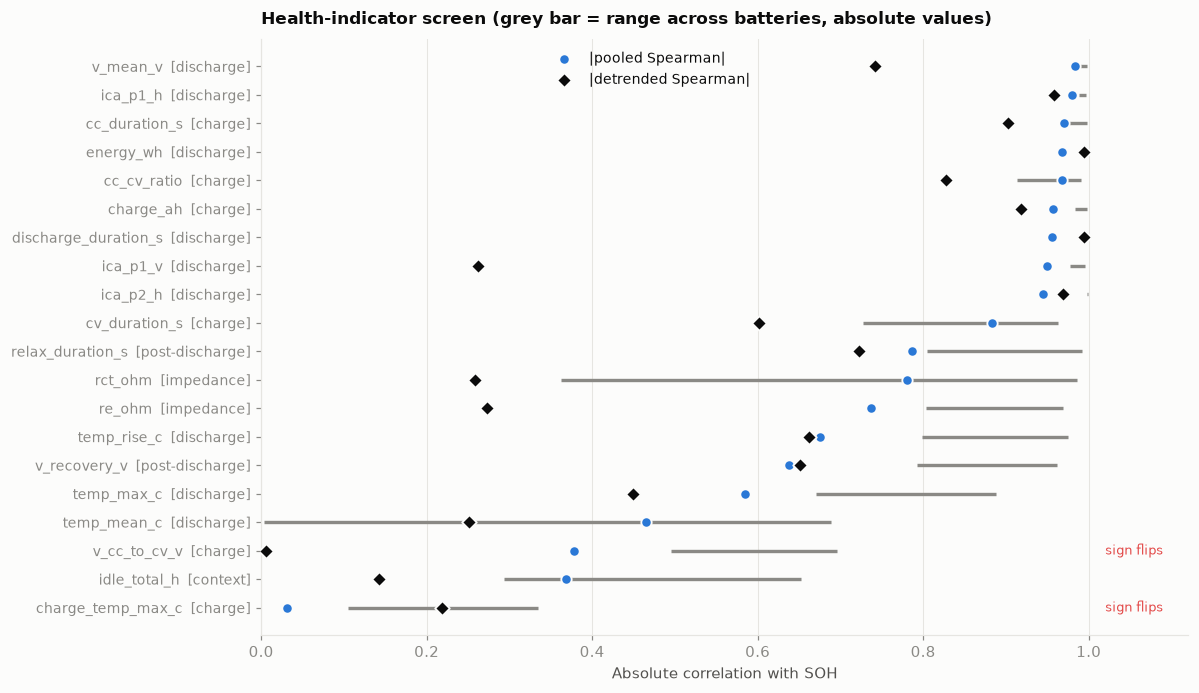

In [25]:
fig, ax = plt.subplots(figsize=(11, 6.4))
s = screen.iloc[::-1].reset_index(drop=True)
y = np.arange(len(s))
ax.hlines(y, s.per_battery_min.abs(), s.per_battery_max.abs(), color=MUTED, lw=2.2)
ax.scatter(s.pooled_spearman.abs(), y, s=46, color=SERIES["B0005"], zorder=5, edgecolor=SURFACE, lw=1.2,
           label="|pooled Spearman|")
ax.scatter(s.detrended_spearman.abs(), y, s=46, marker="D", color=INK, zorder=5, edgecolor=SURFACE, lw=1.2,
           label="|detrended Spearman|")
labels = [f"{r.indicator}  [{r['measured on']}]" for _, r in s.iterrows()]
ax.set_yticks(y); ax.set_yticklabels(labels, fontsize=9)
for yi, r in s.iterrows():
    if not r.sign_consistent:
        ax.text(1.02, yi, "sign flips", fontsize=8.5, color=ACCENT_BAD, va="center")
ax.set_xlim(0, 1.12)
style(ax, "Health-indicator screen (grey bar = range across batteries, absolute values)",
      "Absolute correlation with SOH", None, grid_axis="x")
ax.legend(fontsize=9, loc="upper center", bbox_to_anchor=(0.42, 1.0))
plt.tight_layout(); plt.show()

### How to read it

Each row is one indicator; its data source is in brackets. The **blue dot** is how strongly
it tracks SOH pooled across batteries. The **grey bar** spans its weakest to strongest single
battery — a long bar means it works well in some cells and poorly in others. The **black
diamond** is the detrended correlation: how well it follows health *beyond* the shared
downward trend.

**Trap 3 — leakage — dominates the top of the chart.** `discharge_duration_s` and
`energy_wh` reach 1.000 within every battery, with detrended scores near 1 too. At a
constant 2 A discharge, duration *is* capacity divided by current, and energy is capacity
times average voltage. They are the target, measured again. `ica_p1_h` is close behind for the same reason, and
`v_mean_v` — top of the pooled ranking — is also measured during that same discharge. Using them to predict the SOH of *their own* cycle would be leakage.
They are only legitimate as **lagged** inputs (a previous cycle's value used to forecast
future cycles).

**Among indicators available before the discharge, charge-phase timing wins:**

- `cc_duration_s` and `charge_ah` — per-battery 0.975–0.998, and detrended ~0.9. They
  follow not just the trend but the cycle-to-cycle ups and downs of regeneration, which means
  they read the cell's actual state rather than its age.
- `cc_cv_ratio` — slightly weaker (0.91–0.99), still strong after detrending.
- `cv_duration_s` — weaker and less consistent.

**Supporting indicators** track the long-term trend but not the short-term state:

- `re_ohm`, `rct_ohm` — detrended only about −0.27; `rct_ohm` also has the widest grey bar
  of any strong indicator, because of B0018.
- `temp_rise_c`, `v_recovery_v` — moderate and consistent.

**Discard:** `v_cc_to_cv_v` and `charge_temp_max_c` flip sign between batteries, and
`temp_mean_c` is near zero for one cell. `idle_total_h` has only a weak detrended correlation with SOH (about 0.14) — as expected, since it explains *jumps* (§3), not the health level.

### 7.2 Recommended feature shortlist for Phase 6

| Tier | Features | Role |
|---|---|---|
| **Primary** (pre-discharge, strong, consistent) | `cc_duration_s`, `charge_ah`, `cc_cv_ratio` | Main SOH inputs |
| **Supporting** | `cv_duration_s`, `re_ohm` (all cells), `rct_ohm` (not B0018, after-charge sweeps), `temp_rise_c`, `v_recovery_v` | Trend and robustness |
| **Context** | `idle_total_h`, cycle count, throughput | Explain regeneration; age baseline |
| **Lagged only** | `discharge_duration_s`, `energy_wh`, `v_mean_v`, `ica_p1_h`, `ica_p1_v`, `ica_p2_h` | Previous-cycle values for forecasting; never same-cycle |
| **Drop** | `v_cc_to_cv_v`, `charge_temp_max_c`, `temp_mean_c` | Inconsistent sign or no signal |

Aborted and partial charges, and the cycle-90 shared-charge rows, must be excluded before
any charge-phase feature is used.

---

## 8. Data-quality log

Everything found so far that a later phase must account for, in one place. Written to
`outputs/data_quality_log.csv`.

In [26]:
dq = pd.DataFrame([
    ("D1", "Phase 3", "rest_before_h is discharge-start spacing, not idle time", "all", "Use idle_total_h; fix pipeline", "open in pipeline"),
    ("D2", "Phase 3", "Missing relaxation tail stored as 0", "B0006 c1-31, B0007 c17-51 (54 cycles)", "Treat as NaN; fix pipeline", "open in pipeline"),
    ("D3", "Phase 3", "Telemetry QC counts miss charge records", "17 charge samples", "Extend QC to paired charge", "open in pipeline"),
    ("D4", "Phase 4", "No charge logged before cycle 90; charge features copied from cycle 89", "B0005/6/7 cycle 90", "Flag qc_charge_shared; exclude charge features", "open in pipeline"),
    ("D5", "Phase 4", "Regeneration count includes sub-mAh steps", "regeneration_summary", "Count rises > 5 mAh", "open in pipeline"),
    ("D6", "Phase 4", "Sampling interval changes with age", "B0005/6/7: 18.6 s to cycle 30, 9.4 s from 31 (18.5 s at 43); B0018 drifts 9.4 to 13.8 s", "Resample curves to a fixed grid", "Phase 6"),
    ("D7", "Phase 4", "Secondary dQ/dV peak (~3.8 V) not resolvable early", "cycles 1-20 all cells, about half of 21-40", "Use main peak (present every cycle); secondary only after ~cycle 40", "Phase 6"),
    ("D8", "Phase 4", "Rct offset depends on sweep context, drifts with age and changes sign", "B0005-7 (B0007 +6.1 mOhm early; B0005 -5.9 mOhm late)", "Use after-charge sweeps only", "Phase 6"),
    ("D9", "Phase 4", "B0018 Rct atypical (not explained by context)", "B0018", "Exclude B0018 Rct; keep cell", "decided"),
    ("D10", "Phase 3/4", "Deep early discharges past cut-off", "21 cycles B0006/B0007", "Shown not to inflate capacity; keep", "closed"),
    ("D11", "Phase 3", "Aborted (5) and partial (4) charges", "cycle 1 all; cycle 31 B0005-7; B0018 46,56", "Exclude from charge features", "flagged"),
    ("D12", "Phase 3", "Leading impedance gap", "cycles 1-19 B0005/6/7 (57)", "Optional feature + missing indicator", "decided"),
    ("D13", "Phase 4", "Test-rig interruptions", "B0005/6/7 cycle 31 (36 h stop, charge stub, sampling switch) and 43 (11 h stop, impedance step)", "Treat as known events; check features for discontinuities", "Phase 5/6"),
], columns=["id", "found in", "issue", "scope", "handling", "status"])
out = resolve("processed").parents[1] / "phase4_eda" / "outputs"
out.mkdir(parents=True, exist_ok=True)
dq.to_csv(out / "data_quality_log.csv", index=False)
screen.to_csv(out / "hi_screening.csv", index=False)
print(dq.to_string(index=False))
print()
print("wrote:", (out / "data_quality_log.csv").name, "and", (out / "hi_screening.csv").name)

 id  found in                                                                  issue                                                                                           scope                                                            handling           status
 D1   Phase 3                rest_before_h is discharge-start spacing, not idle time                                                                                             all                                      Use idle_total_h; fix pipeline open in pipeline
 D2   Phase 3                                    Missing relaxation tail stored as 0                                                           B0006 c1-31, B0007 c17-51 (54 cycles)                                          Treat as NaN; fix pipeline open in pipeline
 D3   Phase 3                                Telemetry QC counts miss charge records                                                                               17 charge samples                      

---

## 9. Findings, decisions and hand-off

### Findings

| # | Finding | Evidence |
|---|---|---|
| **F1** | Degradation over the recorded life is close to **linear**; there is **no knee** | Linear R² 0.94–0.98; two-piece fits show mild acceleration in B0005/B0007 and deceleration in B0006/B0018 (§2.2) |
| **F2** | Cells do **not** follow one universal curve | 7–10 pp SOH spread at every life fraction; B0006 lowest throughout (§2.4) |
| **F3** | Early fade ranks the three labelled cells in EOL order | Loss by cycle 20: B0018 > B0006 > B0005, EOL 97 < 109 < 125 — suggestive only, n = 3 (§2.5) |
| **F4** | Most counted "regeneration" is noise; real jumps are few | Only 13–20 rises above 5 mAh per cell vs 21–47 counted (§3.1) |
| **F5** | **Long idle periods drive regeneration** — overturns Phase 3 | Share of cycles rising >5 mAh: under 4% after <4 h idle, 68% after 4–24 h, 100% after >24 h; all 12 largest jumps follow more than a day idle (§3.3) |
| **F6** | Capacity plateaus are real, not a storage artefact | Recorded and integrated capacity change together, correlation 0.94–1.00 (§3.4) |
| **F7** | Discharge curves shorten and shift down; CC phase shrinks; both dQ/dV peaks lower and shift left, main peak present in every cycle | §4.1, §4.2, §4.5 |
| **F8** | Sampling interval changes with age — a confound for curve features | Step from 18.6 s to 9.4 s at cycle 31 (B0005–7); gradual 9.4 → 13.8 s (B0018) (§4.4) |
| **F9** | Deep early discharges **do not** inflate capacity — Phase 3 Finding 5 closed | Recorded vs cut-off capacity within ±16 mAh, flagged ≈ unflagged (§5) |
| **F10** | Rct carries a sweep-context offset | Offset drifts with age and changes sign (B0007 +6.1 mΩ early; B0005 −5.9 mΩ late), comparable to lifetime rise (§6.2) |
| **F11** | B0018's Rct is atypical and **not** explained by context; its Re is normal | §6.3 |
| **F12** | Discharge-side indicators are the target in disguise | `discharge_duration_s`, `energy_wh` = 1.000 within every cell (§7) |
| **F13** | Best pre-discharge indicators: `cc_duration_s`, `charge_ah`, `cc_cv_ratio` | Per-battery ≥ 0.91, detrended 0.83–0.92 (§7) |
| **F14** | New pipeline defect: cycle 90 inherits cycle 89's charge record | B0005/6/7 (§1.2) |
| **F15** | Test-rig interruptions at cycles 31 and 43 (B0005–7) coincide with capacity jumps, a sampling change and an impedance step | §3.3, §4.4, §6.1 |

### Decisions

1. **SOH target:** raw capacity, with an envelope target evaluated as a secondary option.
2. **Features:** the tiered shortlist in §7.2; discharge-side values only ever lagged.
3. **B0018:** keep the cell, drop its Rct.
4. **Impedance:** optional, with a missing indicator, one sweep context.
5. **Curve features:** resample to a fixed grid; use the main dQ/dV peak throughout, the
   secondary peak only after ~cycle 40.
6. **Deep-discharge cycles:** keep.

### Hand-off

**To the Phase 3 pipeline** — fix D1–D5 (idle time, missing tail as NaN, charge QC, shared
charge flag, regeneration threshold), rebuild, and update the tests.

**To Phase 5 (targets and evaluation protocol):**
- With no knee in the data (F1), state explicitly that models cannot be expected to
  predict one.
- Cell-to-cell variation (F2) with three labelled cells means leave-one-battery-out RUL
  error will be large and uncertain; report per fold, not just the average.
- Evaluate early-life prediction (F3) but frame any success as a hypothesis.
- Treat cycles 31 and 43 of B0005–B0007 as known events when designing temporal splits (F15).

**To Phase 6 (features):** implement §7.2, the sampling-rate correction (F8) and the
impedance context control (F10), and the test-rig event markers (F15).